In [1]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec
import glob 
import seaborn as sns
from brokenaxes import brokenaxes
from frechetdist import frdist
from scipy.ndimage import gaussian_filter
from dipy.segment.metricspeed import AveragePointwiseEuclideanMetric
import ast
import scipy.stats as stats
from scipy.stats import f_oneway


import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from streamline_clustering.clustering import pair_elements,create_streamlines
from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis,edge_outliers,create_df_by_type_nostart,find_consecutive_repeats,largest_sequentially_increasing_by_one_subarray,create_color_dict,smooth,create_monotonic_array,correct_trace
#from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,calculate_speed,deveation,lateral_error,start,redo_ts_trace,compute_tortuosity,angular_velocity_head,turn_direction,turn_to_obstacle,get_head_angle,head_angle_velocity,intial_lateral_error,avg_lateral_error,check_trial_for_obstalce_cross_df,distance_at_head_turn,zero_out_angle_target_port,angular_velocity_head_corner,intial_distance_to_obstacle,last_occurrence_indices,first_occurrence_indices,angle_to_open_corner,turn_direction_left_right
from pipeline.oa_calculations import *
from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row
from pipeline.batch_process_oa import plot_oa

Loading DLC 2.3.0...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


In [2]:
test = pd.read_hdf(r"D:\obstacle_avoidance\metadata\obstacle_avoidance_paper\joint.h5")
test1 = pd.read_hdf(r"D:\obstacle_avoidance\metadata\obstacle_avoidance_paper\joint1.h5")
joint = pd.concat([test,test1])

turn_direction(joint)
turn_to_obstacle(joint)
heading_calcs(joint)
get_head_angle(joint)
head_angle_velocity(joint)
angular_velocity_head_corner(joint)
distance_at_head_turn(joint)
calculate_speed(joint)
intial_lateral_error(joint)
avg_lateral_error(joint)
get_initial_turn_direction(joint)
get_head_angle_whole_trial(joint)
angular_velocity_head_whole_trial(joint)

long_nostart,short_nostart,middle_nostart = create_df_by_type_nostart(joint)
#long_con_nostart,short_con_nostart,middle_con_nostart = create_df_by_type_nostart(con_df)

long,short,middle = create_df_by_type(joint)

corner
port
[ 1 29 51 80]
[  2  18  41 163 187]
[105 123]
[ 32  69 172]
[]
[ 18  69  93 136 151 176 200 321]
[13 90]
[ 3 23 59]
[104 132]
[ 33  60 103]
[ 54  72 104 208 224]
[21 35 68]
[ 16  29 227 246]
[  3  39 153 203 222]
[5]
[16 48 74 85]
[ 3 47 66 76]
[21]
[65 83]
[ 5 17 32 56]
[ 16  45  65  77 204 220]
[ 6 27]
[ 24  78 115]
[ 7 31 50]
[ 9 22 40 51 61]
[ 46  63  83 109 128 170]
[20]
[146 179 189 244]
[ 17  48 129]
[ 23  68 180 205]
[ 5 31]
[17 56 70 92]
[  9  32  60 150 170 208]
[ 18  84  98 116]
[15 54]
[  5  16 101 170]
[13 40 53]
[  3  72 119]
[ 24  73 110 143]
[4]
[  3  64  81 112]
[12 99]
[30]
[20]
[41]
[103]
[ 2 17 38 59]
[46 57 69]
[3]
[ 9 36]
[57 82]
[  5  28  59  80  98 121 179 236]
[30 58 73 95]
[ 41 108 141 202 212 242]
[ 92 106 119 183 209 236]
[ 74 102 127 149]
[ 4 19]
[  6  41 119]
[  7  25  46  82  97 158]
[2]
[64]
[ 11  62 132]
[10]
[ 8 32 48]
[34 45]
[ 2 12 55 81]
[19 53]
[11 26 75]
[36 52 65]
[13 54]
[2]
[19]
[13 25 69]
[ 3 37 60]
[ 2 25 48]
[ 26 143 181]
[21]
[ 

In [ ]:
get_head_angle_whole_trial(joint)
angular_velocity_head_whole_trial(joint)

In [5]:
get_initial_turn_direction(joint)

In [3]:
long_nostart,short_nostart,middle_nostart = create_df_by_type_nostart(joint)
#long_con_nostart,short_con_nostart,middle_con_nostart = create_df_by_type_nostart(con_df)

long,short,middle = create_df_by_type(joint)

In [4]:
long.head_angle_velocity_whole_trial

8        [-0.7889109863396171, -1.2130015355926194, -1....
17       [-0.16380271173372485, -0.24914577199065757, -...
24       [-0.20729661037794278, -0.3713595448874485, -0...
27       [-0.1603806542532138, -0.2914436539767906, -0....
29       [0.23206932613603293, 0.83138615387228, 1.7348...
                               ...                        
14456    [1.6765886113843753, 3.0075780837028687, 3.781...
14459    [1.07115135543151, 1.9613305097959222, 2.55258...
14479    [0.9313083295421754, 1.898688198525278, 2.7973...
14481    [1.2041506380405886, 2.222104063932373, 2.9953...
14523    [1.6347577660386703, 2.8529514558113167, 3.478...
Name: head_angle_velocity_whole_trial, Length: 3407, dtype: object

<AxesSubplot: >

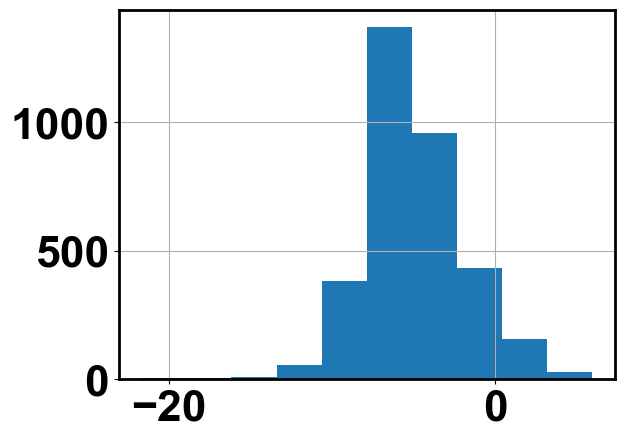

In [188]:
long.avg_lateral_error.hist()

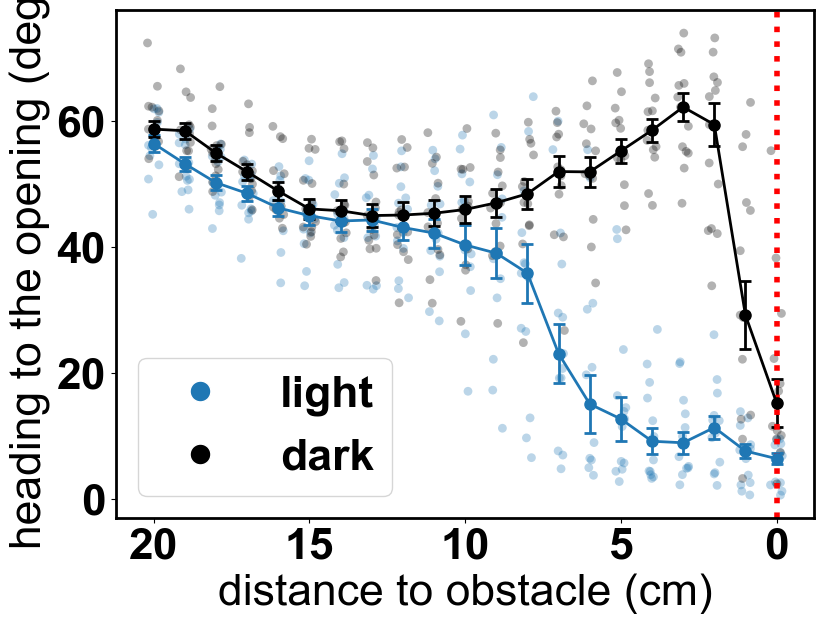

meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


In [185]:
# Set font parameters to match previous plots
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
font = {'family': 'arial',
        'size': 32}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([long])
data = drop_nans_in_columns(data, 'obstacle_ind')

# Storage for data
light_medians = []
dark_medians = []
light_scatter = []  # For individual animal points
dark_scatter = []   # For individual animal points

for task, task_df in data.groupby(['task']):
    # Process each animal
    for animal, animal_df in task_df.groupby(['animal']):
        angle_array = np.empty([animal_df.shape[0], len(xnew)])
        angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate population statistics
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_angle_median = np.nanmedian(light_medians, axis=0)
dark_angle_median = np.nanmedian(dark_medians, axis=0)

# Calculate standard error instead of standard deviation
light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(np.sum(~np.isnan(light_medians), axis=0))
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(np.sum(~np.isnan(dark_medians), axis=0))

# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with SEM error bars
ax.errorbar(xnew, light_angle_median, yerr=light_sem, 
           fmt='-', color='tab:blue', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem, 
           fmt='-', color='black', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting to match previous plots
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([0,20,40,60])
ax.set_ylabel('heading to the opening (deg)', fontsize=32)
ax.set_xlabel('distance to obstacle (cm)', fontsize=32)
ax.axvline(0, color='r', ls=':', linewidth=4)

# Legend with matching style
ax.legend(loc='lower left', fontsize=32, framealpha=0.8)

# Create custom legend handles
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=15)
]

# Update your legend call
ax.legend(handles=legend_handles, loc='lower left', fontsize=32, framealpha=0.8)




plt.tight_layout()
plt.show()
plt.rcParams["font.weight"] = "bold"
fig.savefig(r"D:\obstacle_avoidance\figures\SC_grant\heading_to_opening_sc_grant.pdf",dpi = 300, transparent=True)

In [ ]:
def goal_port(df):
    for ind,row in df.iterrows():
        ob_ind = int(row.obstacle_ind)
        df.at[ind,'goal_distance_from_target_port'] = row.ts_distance_from_target_port[ob_ind:].astype(object)
        df.at[ind,'goal_angle_to_target_port'] = row.ts_angle_to_target_port[ob_ind:].astype(object)
        df.at[ind,'goal_lateral_error_to_target_port'] = row.ts_lateral_error_to_target_port[ob_ind:].astype(object)

In [33]:
test = long.sample(1)
for ind,row in test.iterrows():
    ob_ind = int(row.obstacle_ind)
    test.at[ind,'goal_distance_from_target_port'] = row.ts_distance_from_target_port[ob_ind:].astype(object)
    test.at[ind,'goal_angle_to_target_port'] = row.ts_angle_to_target_port[ob_ind:].astype(object)
    test.at[ind,'goal_lateral_error_to_target_port'] = row.ts_lateral_error_to_target_port[ob_ind:].astype(object)

In [36]:
ob_ind

98

In [40]:
row.ts_nose_x_cm

array([49.966304377362725, 49.78526160124141, 49.63808205347188,
       49.49427134145119, 49.42964627094084, 49.39623050626868,
       49.08694052496029, 48.822967813549766, 48.6361491556789,
       48.39927628481904, 48.09275852102001, 47.952707532560254,
       47.69928364881521, 47.44490311858271, 47.3534559435987,
       47.13223915826479, 46.94480845237237, 46.71705972596817,
       46.69847712511231, 46.636073943217994, 46.220200170728866,
       46.078019872345415, 45.90410051227319, 45.83940857937393,
       45.795047955963526, 45.764836442698275, 45.715872600974556,
       45.659409885171726, 45.61979134811313, 45.698498666379734,
       45.72273885398939, 45.767253775220354, 45.77630077076574,
       45.73047946132071, 45.74134202788799, 45.731636694974895,
       45.706311279360655, 45.56071071262149, 45.47841854165726,
       45.325648269522844, 45.46546781125176, 45.32191940552603,
       44.89877820568862, 44.7152255183529, 44.5900951291411,
       44.402186100004954, 44

In [39]:
row.ts_angle_to_target_port

array([65.79137553168192, 66.02211285052772, 67.9198800477266,
       68.6806890358586, 69.42779329807264, 71.8836925344715,
       72.29830232161243, 72.8300129304177, 71.40570205372507,
       72.48845580741174, 71.00666466904718, 70.14040824568066,
       73.55373944403004, 74.14014368570854, 74.34074904672225,
       71.57427124575166, 72.02884405895246, 72.12136728492386,
       73.64411062381106, 74.62145328964037, 71.52562632313494,
       69.28021716044336, 67.38373467089892, 68.40306698627708,
       69.30727715224442, 69.1678024488343, 66.06721849349779,
       67.53569283742594, 64.6077395935381, 63.039929212353165,
       65.58375438888748, 65.65904012808913, 66.41721397066846,
       66.40601830916421, 67.31315591573725, 67.4401092980471,
       66.37201170979682, 65.80994599154423, 64.60709670819259,
       61.577132999237186, 63.08961944457985, 61.00942544496877,
       53.37372646915199, 51.01621181157698, 45.824430631539926,
       47.49057085802494, 46.28754182014571,

In [35]:
row.ts_distance_from_target_port[ob_ind:].astype(object)

array([], dtype=object)

In [ ]:
calculate_relative_distance_goal_ts(long)
goal_port(long)

In [184]:
avg_lateral_error(long)

In [154]:
avg_lateral_error(joint)

In [190]:
avg_lateral_error(long_nostart)

In [131]:
long

,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,angle_before_head_turn,head_turn_velocity,angles_at_head_turns,distances_at_head_turns,angles_at_head_turns_ends,avg_speed,avg_ts_speed,head_angle_whole_trial,head_angle_velocity_whole_trial,turn_direction_left_right
8,8,48098.019340,48102.816128,"[48098.031385, 48098.048576, 48098.06464, 4809...","[[3308, 3309, 3310, 3311, 3312, 3313, 3314, 33...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[649.9629516601562, 650.8632202148438, 650.746...","[252.6468963623047, 251.91566467285156, 251.48...","[656.01318359375, 656.386474609375, 656.445373...",...,68.444419,4.699180,[10.179569813810865],[1.8804369365781402],[3.7884585185741315],20.809365,20.891983,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-0.7889109863396171, -1.2130015355926194, -1....",left
17,17,48338.593881,48344.042022,"[48338.598041, 48338.614617, 48338.631424, 483...","[[17737, 17738, 17739, 17740, 17741, 17742, 17...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[650.9925537109375, 652.1788330078125, 652.823...","[254.21148681640625, 254.0948028564453, 254.07...","[656.2599487304688, 657.4254150390625, 658.723...",...,NaN,NaN,[nan],[nan],[nan],17.862486,17.851822,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-0.16380271173372485, -0.24914577199065757, -...",right
24,24,48420.115289,48424.506713,"[48420.126092, 48420.143462, 48420.159539, 484...","[[22627, 22628, 22629, 22630, 22631, 22632, 22...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[647.6133422851562, 648.2860107421875, 648.863...","[258.9119873046875, 258.0534973144531, 257.625...","[656.2706298828125, 656.6029052734375, 656.868...",...,64.665816,9.321765,"[45.577345895546785, 13.182066028787332, 37.59...","[19.126954831503788, 12.68730852308991, 6.2272...","[27.188639381374767, 1.3618100704771021, 61.16...",25.031042,26.860749,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-0.20729661037794278, -0.3713595448874485, -0...",left
27,27,48451.833305,48459.674124,"[48451.837196, 48451.85399, 48451.870681, 4845...","[[24529, 24530, 24531, 24532, 24533, 24534, 24...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[647.6234741210938, 647.111083984375, 647.8052...","[258.09979248046875, 256.70001220703125, 256.1...","[653.6805419921875, 654.243408203125, 654.8812...",...,65.492813,5.766666,"[64.36320042000398, 19.401423323519154, 1.4630...","[22.825084479564573, 10.33840211610704, 4.6596...","[53.688582155444315, 3.3396438107411224, 8.461...",12.043630,12.924533,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-0.1603806542532138, -0.2914436539767906, -0....",left
29,29,48467.768192,48473.544102,"[48467.77591, 48467.792857, 48467.810598, 4846...","[[25485, 25486, 25487, 25488, 25489, 25490, 25...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[651.9254150390625, 652.91552734375, 653.34338...","[251.62893676757812, 252.2069091796875, 252.18...","[655.7667236328125, 656.9116821289062, 658.112...",...,33.807077,16.831029,"[67.75946009147836, 59.0662412581965, 25.76573...","[22.689007941167716, 4.286593988791843, 2.3113...","[34.78286736958878, 73.9431105761609, 26.02651...",19.450888,19.241862,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.23206932613603293, 0.83138615387228, 1.7348...",right
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14456,14456,58284.241510,58286.769433,"[58284.250803, 58284.267686, 58284.284518, 582...","[10663, 10664, 10665, 10666, 10667, 10668, 106...","[87.75959014892578, 86.99541473388672, 86.5253...","[260.9606018066406, 261.192138671875, 260.8676...","[101.29974365234375, 99.75284576416016, 98.431...","[25

In [133]:
long_nostart.inital_lateral_error

AttributeError: 'DataFrame' object has no attribute 'inital_lateral_error'

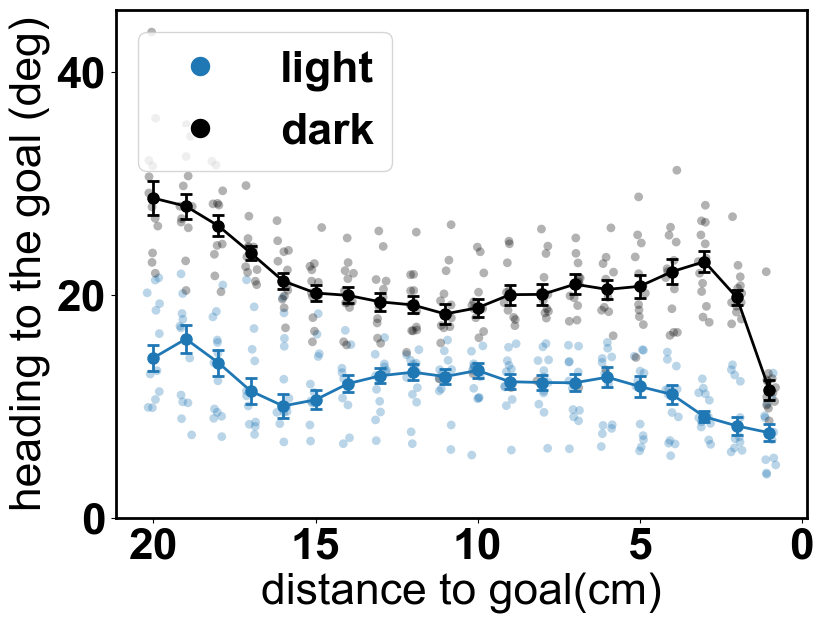

meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


In [82]:
# Set font parameters to match previous plots
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
font = {'family': 'arial',
        
        'size': 32}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([long])
data = drop_nans_in_columns(data, 'obstacle_ind')

# Storage for data
light_medians = []
dark_medians = []
light_scatter = []  # For individual animal points
dark_scatter = []   # For individual animal points

for task, task_df in data.groupby(['task']):
    # Process each animal
    for animal, animal_df in task_df.groupby(['animal']):
        angle_array = np.empty([animal_df.shape[0], len(xnew)])
        angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['goal_distance_from_target_port'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['goal_angle_to_target_port'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate population statistics
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_angle_median = np.nanmedian(light_medians, axis=0)
dark_angle_median = np.nanmedian(dark_medians, axis=0)

light_sd = np.nanstd(light_medians, axis=0)
dark_sd = np.nanstd(dark_medians, axis=0)

light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(np.sum(~np.isnan(light_medians), axis=0))
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(np.sum(~np.isnan(dark_medians), axis=0))


# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars
ax.errorbar(xnew, light_angle_median, yerr=light_sem, 
           fmt='-', color='tab:blue', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem, 
           fmt='-', color='black', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting to match previous plots
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([0,20,40])
ax.set_ylabel('heading to the goal (deg)', fontsize=32)
ax.set_xlabel('distance to goal(cm)', fontsize=32)
#ax.axvline(0, color='r', ls=':', linewidth=2)

# Create custom legend handles
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=15)
]

# Legend with matching style
# Update your legend call
ax.legend(handles=legend_handles, loc='upper left', fontsize=32, framealpha=0.8)

# Grid lines for readability


plt.tight_layout()
plt.show()
plt.rcParams["font.weight"] = "bold"

fig.savefig(r"D:\obstacle_avoidance\figures\SC_grant\heading_to_opening_goal_sc_grant.pdf",dpi = 300, transparent=True)

In [134]:
long.turn_towards

AttributeError: 'DataFrame' object has no attribute 'turn_towards'

In [106]:
oa_data


,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,distances_at_head_turns,angles_at_head_turns_ends,avg_speed,avg_ts_speed,head_angle_whole_trial,head_angle_velocity_whole_trial,turn_direction_left_right,goal_distance_from_target_port,goal_angle_to_target_port,goal_lateral_error_to_target_port
8,8,48098.019340,48102.816128,"[48098.031385, 48098.048576, 48098.06464, 4809...","[[3308, 3309, 3310, 3311, 3312, 3313, 3314, 33...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[649.9629516601562, 650.8632202148438, 650.746...","[252.6468963623047, 251.91566467285156, 251.48...","[656.01318359375, 656.386474609375, 656.445373...",...,[1.8804369365781402],[3.7884585185741315],20.809365,20.891983,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-0.7889109863396171, -1.2130015355926194, -1....",left,"[20.536981549518085, 20.51853830041654, 20.361...","[22.04616869944721, 28.159448450055024, 33.387...","[3.6050216160984014, 3.861027239236588, 4.1436..."
17,17,48338.593881,48344.042022,"[48338.598041, 48338.614617, 48338.631424, 483...","[[17737, 17738, 17739, 17740, 17741, 17742, 17...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[650.9925537109375, 652.1788330078125, 652.823...","[254.21148681640625, 254.0948028564453, 254.07...","[656.2599487304688, 657.4254150390625, 658.723...",...,[nan],[nan],17.862486,17.851822,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-0.16380271173372485, -0.24914577199065757, -...",right,"[22.46647368419632, 22.210636822954093, 21.974...","[29.27554420899936, 28.02386546266077, 28.1157...","[3.578414633038829, 3.7735599341282295, 3.9453..."
24,24,48420.115289,48424.506713,"[48420.126092, 48420.143462, 48420.159539, 484...","[[22627, 22628, 22629, 22630, 22631, 22632, 22...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[647.6133422851562, 648.2860107421875, 648.863...","[258.9119873046875, 258.0534973144531, 257.625...","[656.2706298828125, 656.6029052734375, 656.868...",...,"[19.126954831503788, 12.68730852308991, 6.2272...","[27.188639381374767, 1.3618100704771021, 61.16...",25.031042,26.860749,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-0.20729661037794278, -0.3713595448874485, -0...",left,"[21.231166203492574, 20.714307559480282, 19.84...","[5.4985704164487395, 9.649263258632539, 7.2602...","[2.985139954262756, 3.297317496898632, 3.37006..."
27,27,48451.833305,48459.674124,"[48451.837196, 48451.85399, 48451.870681, 4845...","[[24529, 24530, 24531, 24532, 24533, 24534, 24...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[647.6234741210938, 647.111083984375, 647.8052...","[258.09979248046875, 256.70001220703125, 256.1...","[653.6805419921875, 654.243408203125, 654.8812...",...,"[22.825084479564573, 10.33840211610704, 4.6596...","[53.688582155444315, 3.3396438107411224, 8.461...",12.043630,12.924533,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-0.1603806542532138, -0.2914436539767906, -0....",left,"[20.998659730374968, 20.416345610881283, 20.13...","[25.897982581342898, 24.269517945326385, 20.31...","[4.481175634418616, 4.789503458458189, 4.95167..."
29,29,48467.768192,48473.544102,"[48467.77591, 48467.792857, 48467.810598, 4846...","[[25485, 25486, 25487, 25488, 25489, 25490, 25...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[651.9254150390625, 652.91552734375, 653.34338...","[251.62893676757812, 252.2069091796875, 252.18...","[655.7667236328125, 656.9116821289062, 658.112...",...,"[22.689007941167716, 4.286593988791843, 2.3113...","[34.78286736958878, 73.9431105761609, 26.02651...",19.450888,19.241862,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.23206932613603293, 0.83138615387228, 1.7348...",right,"[21.2

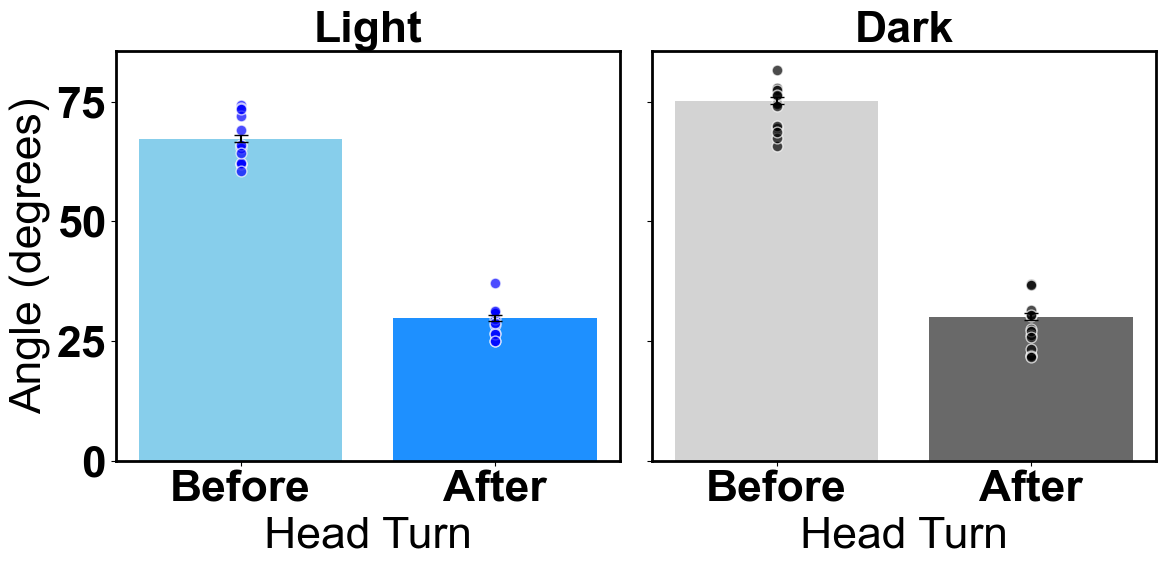

In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Panel 1: oa data (light - blue)
oa_data = long[long['task'] == 'oa']

# Calculate means and standard errors for oa data
oa_before_mean = oa_data['angle_before_head_turn'].mean()
oa_before_se = oa_data['angle_before_head_turn'].sem()
oa_after_mean = oa_data['angle_after_head_turn'].mean()
oa_after_se = oa_data['angle_after_head_turn'].sem()

# Plot bars with error bars
ax1.bar(0, oa_before_mean, yerr=oa_before_se, color='skyblue', capsize=5, label='Before')
ax1.bar(1, oa_after_mean, yerr=oa_after_se, color='dodgerblue', capsize=5, label='After')

# Add individual animal means as scatter points
for animal in oa_data['animal'].unique():
    animal_data = oa_data[oa_data['animal'] == animal]
    before_mean = animal_data['angle_before_head_turn'].mean()
    after_mean = animal_data['angle_after_head_turn'].mean()
    ax1.scatter([0], [before_mean], color='blue', alpha=0.7, s=60, edgecolor='white')
    ax1.scatter([1], [after_mean], color='blue', alpha=0.7, s=60, edgecolor='white')

ax1.set_title('Light', fontweight='bold')
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Before', 'After'])
ax1.set_ylabel('Angle (degrees)')
ax1.set_xlabel('Head Turn')

# Panel 2: oadark data (dark - black)
oadark_data = long[long['task'] == 'oadark']

# Calculate means and standard errors for oadark data
oadark_before_mean = oadark_data['angle_before_head_turn'].mean()
oadark_before_se = oadark_data['angle_before_head_turn'].sem()
oadark_after_mean = oadark_data['angle_after_head_turn'].mean()
oadark_after_se = oadark_data['angle_after_head_turn'].sem()

# Plot bars with error bars
ax2.bar(0, oadark_before_mean, yerr=oadark_before_se, color='lightgray', capsize=5, label='Before')
ax2.bar(1, oadark_after_mean, yerr=oadark_after_se, color='dimgray', capsize=5, label='After')

# Add individual animal means as scatter points
for animal in oadark_data['animal'].unique():
    animal_data = oadark_data[oadark_data['animal'] == animal]
    before_mean = animal_data['angle_before_head_turn'].mean()
    after_mean = animal_data['angle_after_head_turn'].mean()
    ax2.scatter([0], [before_mean], color='black', alpha=0.7, s=60, edgecolor='white')
    ax2.scatter([1], [after_mean], color='black', alpha=0.7, s=60, edgecolor='white')

ax2.set_title('Dark', fontweight='bold')
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Before', 'After'])
ax2.set_xlabel('Head Turn')

# Adjust layout and show plot
plt.tight_layout()
plt.show()

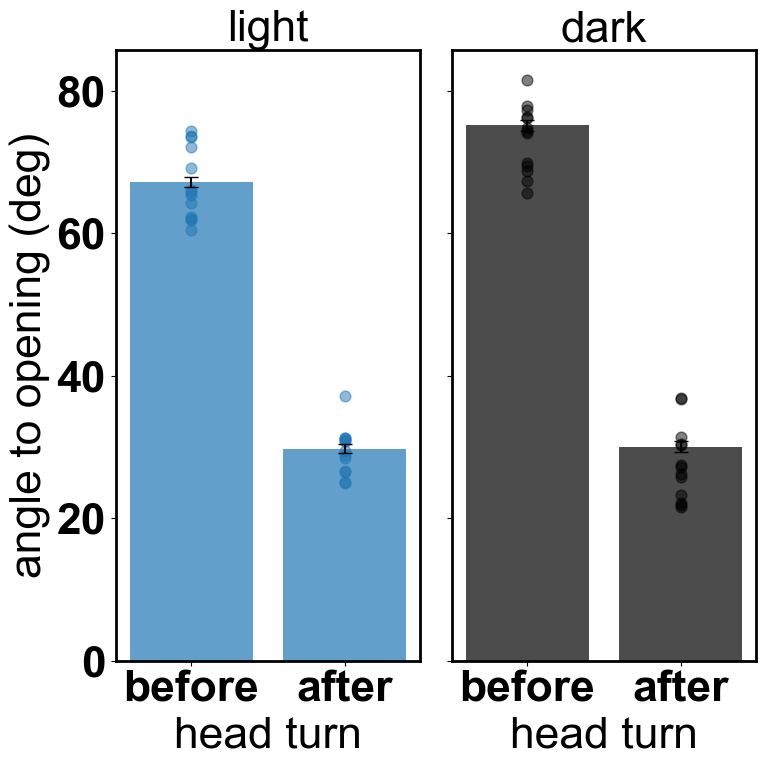

meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


In [120]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 8), sharey=True)

# panel 1: oa data (light - tab:blue)
oa_data = long[long['task'] == 'oa']

# calculate means and standard errors for oa data
oa_before_mean = oa_data['angle_before_head_turn'].mean()
oa_before_se = oa_data['angle_before_head_turn'].sem()
oa_after_mean = oa_data['angle_after_head_turn'].mean()
oa_after_se = oa_data['angle_after_head_turn'].sem()

# plot bars with error bars (both tab:blue)
ax1.bar(0, oa_before_mean, yerr=oa_before_se, color='tab:blue', capsize=5, alpha=0.7)
ax1.bar(1, oa_after_mean, yerr=oa_after_se, color='tab:blue', capsize=5, alpha=0.7)

# add individual animal means as scatter points (tab:blue)
for animal in oa_data['animal'].unique():
    animal_data = oa_data[oa_data['animal'] == animal]
    before_mean = animal_data['angle_before_head_turn'].mean()
    after_mean = animal_data['angle_after_head_turn'].mean()
    ax1.scatter([0], [before_mean], color='tab:blue', alpha=0.5, s=60)
    ax1.scatter([1], [after_mean], color='tab:blue', alpha=0.5, s=60)

ax1.set_title('light')
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['before', 'after'])
ax1.set_ylabel('angle to opening (deg)')
ax1.set_xlabel('head turn')

# panel 2: oadark data (dark - black)
oadark_data = long[long['task'] == 'oadark']

# calculate means and standard errors for oadark data
oadark_before_mean = oadark_data['angle_before_head_turn'].mean()
oadark_before_se = oadark_data['angle_before_head_turn'].sem()
oadark_after_mean = oadark_data['angle_after_head_turn'].mean()
oadark_after_se = oadark_data['angle_after_head_turn'].sem()

# plot bars with error bars (both black)
ax2.bar(0, oadark_before_mean, yerr=oadark_before_se, color='black', capsize=5, alpha=0.7)
ax2.bar(1, oadark_after_mean, yerr=oadark_after_se, color='black', capsize=5, alpha=0.7)

# add individual animal means as scatter points (black)
for animal in oadark_data['animal'].unique():
    animal_data = oadark_data[oadark_data['animal'] == animal]
    before_mean = animal_data['angle_before_head_turn'].mean()
    after_mean = animal_data['angle_after_head_turn'].mean()
    ax2.scatter([0], [before_mean], color='black', alpha=0.5, s=60)
    ax2.scatter([1], [after_mean], color='black', alpha=0.5, s=60)

ax2.set_title('dark')
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['before', 'after'])
ax2.set_xlabel('head turn')

# adjust layout and show plot
plt.tight_layout()
plt.show()
fig.savefig(r"D:\obstacle_avoidance\figures\SC_grant\angle_at_headturn_bar.pdf",dpi = 300, transparent=True)

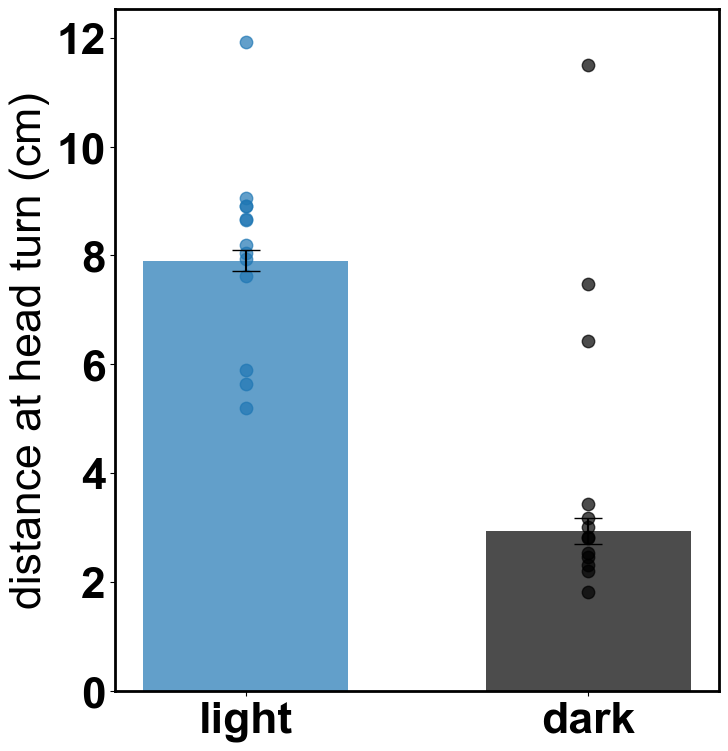

meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


In [129]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# create figure with two subplots

# Prepare data
light_data = long[long['task'] == 'oa']
dark_data = long[long['task'] == 'oadark']

# Calculate medians and standard errors
light_median = light_data['distance_at_head_turn'].median()
light_se = light_data['distance_at_head_turn'].sem()
dark_median = dark_data['distance_at_head_turn'].median()
dark_se = dark_data['distance_at_head_turn'].sem()

# Create figure
fig,ax = plt.subplots(figsize=(8, 8))

# Plot bars with error bars
ax.bar(0, light_median, yerr=light_se, color='tab:blue', 
        alpha=0.7, capsize=10, width=0.6, label='light')
ax.bar(1, dark_median, yerr=dark_se, color='black', 
        alpha=0.7, capsize=10, width=0.6, label='dark')

# Add individual animal points for light condition
for i, animal in enumerate(light_data['animal'].unique()):
    animal_dist = light_data[light_data['animal'] == animal]['distance_at_head_turn'].median()
    ax.scatter(0, animal_dist, color='tab:blue', s=80, alpha=0.7,)

# Add individual animal points for dark condition
for i, animal in enumerate(dark_data['animal'].unique()):
    animal_dist = dark_data[dark_data['animal'] == animal]['distance_at_head_turn'].median()
    ax.scatter(1, animal_dist, color='black', s=80, alpha=0.7,)

# Customize plot
ax.set_xticks([0, 1], ['light', 'dark'])
ax.set_ylabel('distance at head turn (cm)')

plt.tight_layout()
plt.show()

fig.savefig(r"D:\obstacle_avoidance\figures\SC_grant\distance_at_headturn_bar.pdf",dpi = 300, transparent=True)

(array([  11.,   17.,   59.,  359., 1954., 2082., 1711.,  893.,  817.,
         171.]),
 array([-21.70068451, -18.43080556, -15.16092661, -11.89104765,
         -8.6211687 ,  -5.35128975,  -2.08141079,   1.18846816,
          4.45834711,   7.72822607,  10.99810502]),
 <BarContainer object of 10 artists>)

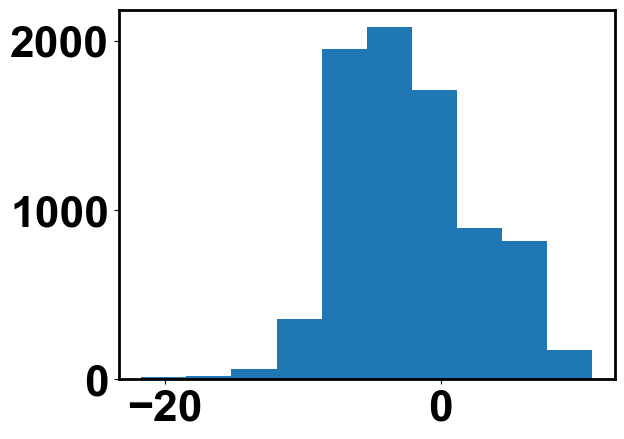

In [161]:
plt.hist(light_dist)

In [ ]:
joint

In [152]:
xnew.shape

(27,)

In [195]:
intial_distance_to_obstacle(joint)

In [201]:
intial_distance_to_obstacle(long_nostart)

In [218]:
intial_distance_to_obstacle(long)

<AxesSubplot: >

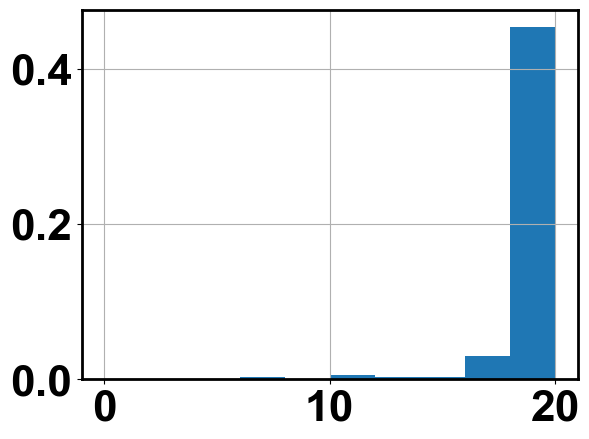

In [202]:
long_nostart.intial_distance.hist(range = (0,20),density=True)

In [205]:
joint

,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,head_turn_velocity,angles_at_head_turns,distances_at_head_turns,angles_at_head_turns_ends,avg_speed,avg_ts_speed,head_angle_whole_trial,head_angle_velocity_whole_trial,turn_direction_left_right,intial_distance
0,0,48054.835737,48059.792371,"[48054.850086, 48054.866291, 48054.883008, 480...","[[718, 719, 720, 721, 722, 723, 724, 725, 726,...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[646.5863647460938, 647.6791381835938, 647.953...","[256.8539123535156, 256.5686340332031, 256.810...","[655.6896362304688, 655.893798828125, 656.1171...",...,15.569130,"[15.15938321217035, 24.259896584310198, 6.5419...","[22.49526474491168, 16.681199698943963, 3.3569...","[0.4748630033916924, 13.206937651525928, 29.11...",17.107891,17.150953,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-2.5067424782757053, -3.975730695107509, -3.9...",left,23.0
1,1,48059.792371,48066.055564,"[48059.801369, 48059.818099, 48059.834739, 480...","[1015, 1016, 1017, 1018, 1019, 1020, 1021, 102...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[100.70337677001953, 100.96659851074219, 100.9...","[229.06690979003906, 229.2141571044922, 229.14...","[97.77118682861328, 97.44432830810547, 97.2664...",...,11.687031,"[15.82125999218137, 28.627561146663947, 103.81...","[11.364698091074153, 6.8218364008299694, 1.653...","[5.1771296691027295, 55.096723742024594, 117.9...",16.703003,16.664893,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[2.681299671880082, 4.408661208135752, 4.82935...",left,12.0
2,2,48066.055564,48070.369088,"[48066.070515, 48066.087513, 48066.103731, 480...","[[1391, 1392, 1393, 1394, 1395, 1396, 1397, 13...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[652.5042114257812, 653.2907104492188, 653.849...","[249.86825561523438, 249.44972229003906, 249.3...","[653.6144409179688, 655.35498046875, 655.19451...",...,5.381417,[25.29977452012463],[7.780990687389513],[49.773470466177024],21.682364,21.810839,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-0.5522916970620639, -0.8708074362329055, -0....",right,24.0
3,3,48070.369088,48076.550553,"[48070.37175, 48070.388352, 48070.40526, 48070...","[1649, 1650, 1651, 1652, 1653, 1654, 1655, 165...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[102.01713562011719, 102.3261489868164, 102.09...","[225.12435913085938, 225.2169189453125, 225.56...","[97.98050689697266, 98.4389877319336, 98.42494...",...,4.847588,"[79.22318919947536, 51.02936468251184]","[3.6178123938312474, 0.5228425681360456]","[43.861660432756864, 64.82904966104601]",14.243221,14.215612,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-0.3559020814814273, -0.5258943041331365, -0....",right,11.0
4,4,48076.550553,48079.610534,"[48076.557094, 48076.574464, 48076.590464, 480...","[[2020, 2021, 2022, 2023, 2024, 2025, 2026, 20...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[652.8433227539062, 653.4661254882812, 654.875...","[250.68643188476562, 250.68145751953125, 250.4...","[650.7364501953125, 652.0059814453125, 654.872...",...,NaN,[nan],[nan],[nan],30.510427,31.092952,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-1.2344531897695687, -2.0689609014932064, -2....",left,24.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14548,14548,56029.032947,56032.629555,"[56029.040921, 56029.057792, 56029.075737, 560...","[[20991, 20992, 20993, 20994, 20995, 20996, 20...","[673.8978271484375, 674.8469848632812, 674.964...","[262.5647277832031, 262.437255859375, 261.6487...","[663.4574584960938, 664.0390014648438, 664.742...","[247.28787231445312, 247.69454956054688, 247.2...","[662.2060546875,

In [206]:
long

,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,angle_before_head_turn,head_turn_velocity,angles_at_head_turns,distances_at_head_turns,angles_at_head_turns_ends,avg_speed,avg_ts_speed,head_angle_whole_trial,head_angle_velocity_whole_trial,turn_direction_left_right
8,8,48098.019340,48102.816128,"[48098.031385, 48098.048576, 48098.06464, 4809...","[[3308, 3309, 3310, 3311, 3312, 3313, 3314, 33...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[649.9629516601562, 650.8632202148438, 650.746...","[252.6468963623047, 251.91566467285156, 251.48...","[656.01318359375, 656.386474609375, 656.445373...",...,68.444419,4.699180,[10.179569813810865],[1.8804369365781402],[3.7884585185741315],20.809365,20.891983,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-0.7889109863396171, -1.2130015355926194, -1....",left
17,17,48338.593881,48344.042022,"[48338.598041, 48338.614617, 48338.631424, 483...","[[17737, 17738, 17739, 17740, 17741, 17742, 17...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[650.9925537109375, 652.1788330078125, 652.823...","[254.21148681640625, 254.0948028564453, 254.07...","[656.2599487304688, 657.4254150390625, 658.723...",...,NaN,NaN,[nan],[nan],[nan],17.862486,17.851822,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-0.16380271173372485, -0.24914577199065757, -...",right
24,24,48420.115289,48424.506713,"[48420.126092, 48420.143462, 48420.159539, 484...","[[22627, 22628, 22629, 22630, 22631, 22632, 22...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[647.6133422851562, 648.2860107421875, 648.863...","[258.9119873046875, 258.0534973144531, 257.625...","[656.2706298828125, 656.6029052734375, 656.868...",...,64.665816,9.321765,"[45.577345895546785, 13.182066028787332, 37.59...","[19.126954831503788, 12.68730852308991, 6.2272...","[27.188639381374767, 1.3618100704771021, 61.16...",25.031042,26.860749,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-0.20729661037794278, -0.3713595448874485, -0...",left
27,27,48451.833305,48459.674124,"[48451.837196, 48451.85399, 48451.870681, 4845...","[[24529, 24530, 24531, 24532, 24533, 24534, 24...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[647.6234741210938, 647.111083984375, 647.8052...","[258.09979248046875, 256.70001220703125, 256.1...","[653.6805419921875, 654.243408203125, 654.8812...",...,65.492813,5.766666,"[64.36320042000398, 19.401423323519154, 1.4630...","[22.825084479564573, 10.33840211610704, 4.6596...","[53.688582155444315, 3.3396438107411224, 8.461...",12.043630,12.924533,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-0.1603806542532138, -0.2914436539767906, -0....",left
29,29,48467.768192,48473.544102,"[48467.77591, 48467.792857, 48467.810598, 4846...","[[25485, 25486, 25487, 25488, 25489, 25490, 25...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[651.9254150390625, 652.91552734375, 653.34338...","[251.62893676757812, 252.2069091796875, 252.18...","[655.7667236328125, 656.9116821289062, 658.112...",...,33.807077,16.831029,"[67.75946009147836, 59.0662412581965, 25.76573...","[22.689007941167716, 4.286593988791843, 2.3113...","[34.78286736958878, 73.9431105761609, 26.02651...",19.450888,19.241862,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.23206932613603293, 0.83138615387228, 1.7348...",right
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14456,14456,58284.241510,58286.769433,"[58284.250803, 58284.267686, 58284.284518, 582...","[10663, 10664, 10665, 10666, 10667, 10668, 106...","[87.75959014892578, 86.99541473388672, 86.5253...","[260.9606018066406, 261.192138671875, 260.8676...","[101.29974365234375, 99.75284576416016, 98.431...","[25

In [204]:
joint[joint.intial_distance>=20]

,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,head_turn_velocity,angles_at_head_turns,distances_at_head_turns,angles_at_head_turns_ends,avg_speed,avg_ts_speed,head_angle_whole_trial,head_angle_velocity_whole_trial,turn_direction_left_right,intial_distance
0,0,48054.835737,48059.792371,"[48054.850086, 48054.866291, 48054.883008, 480...","[[718, 719, 720, 721, 722, 723, 724, 725, 726,...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[646.5863647460938, 647.6791381835938, 647.953...","[256.8539123535156, 256.5686340332031, 256.810...","[655.6896362304688, 655.893798828125, 656.1171...",...,15.569130,"[15.15938321217035, 24.259896584310198, 6.5419...","[22.49526474491168, 16.681199698943963, 3.3569...","[0.4748630033916924, 13.206937651525928, 29.11...",17.107891,17.150953,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-2.5067424782757053, -3.975730695107509, -3.9...",left,23.0
2,2,48066.055564,48070.369088,"[48066.070515, 48066.087513, 48066.103731, 480...","[[1391, 1392, 1393, 1394, 1395, 1396, 1397, 13...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[652.5042114257812, 653.2907104492188, 653.849...","[249.86825561523438, 249.44972229003906, 249.3...","[653.6144409179688, 655.35498046875, 655.19451...",...,5.381417,[25.29977452012463],[7.780990687389513],[49.773470466177024],21.682364,21.810839,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-0.5522916970620639, -0.8708074362329055, -0....",right,24.0
4,4,48076.550553,48079.610534,"[48076.557094, 48076.574464, 48076.590464, 480...","[[2020, 2021, 2022, 2023, 2024, 2025, 2026, 20...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[652.8433227539062, 653.4661254882812, 654.875...","[250.68643188476562, 250.68145751953125, 250.4...","[650.7364501953125, 652.0059814453125, 654.872...",...,NaN,[nan],[nan],[nan],30.510427,31.092952,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-1.2344531897695687, -2.0689609014932064, -2....",left,24.0
5,5,48079.610534,48087.872768,"[48079.625971, 48079.641664, 48079.658304, 480...","[2204, 2205, 2206, 2207, 2208, 2209, 2210, 221...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[101.13579559326172, 101.08495330810547, 100.7...","[228.3592071533203, 228.20135498046875, 228.29...","[97.46910858154297, 97.31474304199219, 97.2201...",...,17.136954,"[9.664639004542767, 12.572894934553617, 11.231...","[20.936629092116107, 20.27657287640787, 20.379...","[7.6513090703920925, 32.433823691669424, 10.11...",13.411771,13.435583,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.36268559162460523, 0.8327748233622589, 1.45...",left,22.0
7,7,48092.632832,48098.019340,"[48092.646604, 48092.66295, 48092.679513, 4809...","[2985, 2986, 2987, 2988, 2989, 2990, 2991, 299...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[92.49336242675781, 92.48167419433594, 92.4443...","[232.90084838867188, 233.29713439941406, 233.3...","[100.34424591064453, 100.15963745117188, 100.2...",...,5.369580,"[32.29834863007902, 13.586973720520975]","[11.077228991701414, 2.0774123271903235]","[13.883617099747935, 24.533747287726175]",19.488010,22.315214,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-2.3470890545905965, -4.167545046574628, -5.1...",right,22.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14531,14531,55880.356185,55883.276800,"[55880.356454, 55880.372979, 55880.390476, 558...","[12073, 12074, 12075, 12076, 12077, 12078, 120...","[88.61856079101562, 88.88373565673828, 88.6142...","[263.3892517089844, 262.6408386230469, 262.672...","[94.50516510009766, 94.44893646240234, 94.1798...","[261.26727294921875, 260.9627685546875, 261.02...","[95.9992065429

In [210]:
dark_bins

array([ 1.  ,  2.35,  3.7 ,  5.05,  6.4 ,  7.75,  9.1 , 10.45, 11.8 ,
       13.15, 14.5 , 15.85, 17.2 , 18.55, 19.9 , 21.25, 22.6 , 23.95,
       25.3 , 26.65, 28.  ])

In [209]:
light_bins

array([ 0.  ,  1.55,  3.1 ,  4.65,  6.2 ,  7.75,  9.3 , 10.85, 12.4 ,
       13.95, 15.5 , 17.05, 18.6 , 20.15, 21.7 , 23.25, 24.8 , 26.35,
       27.9 , 29.45, 31.  ])

<AxesSubplot: >

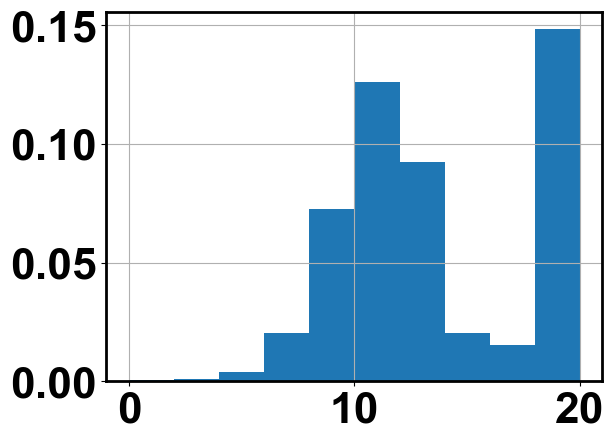

In [200]:
joint.intial_distance.hist(range = (0,20),density=True)

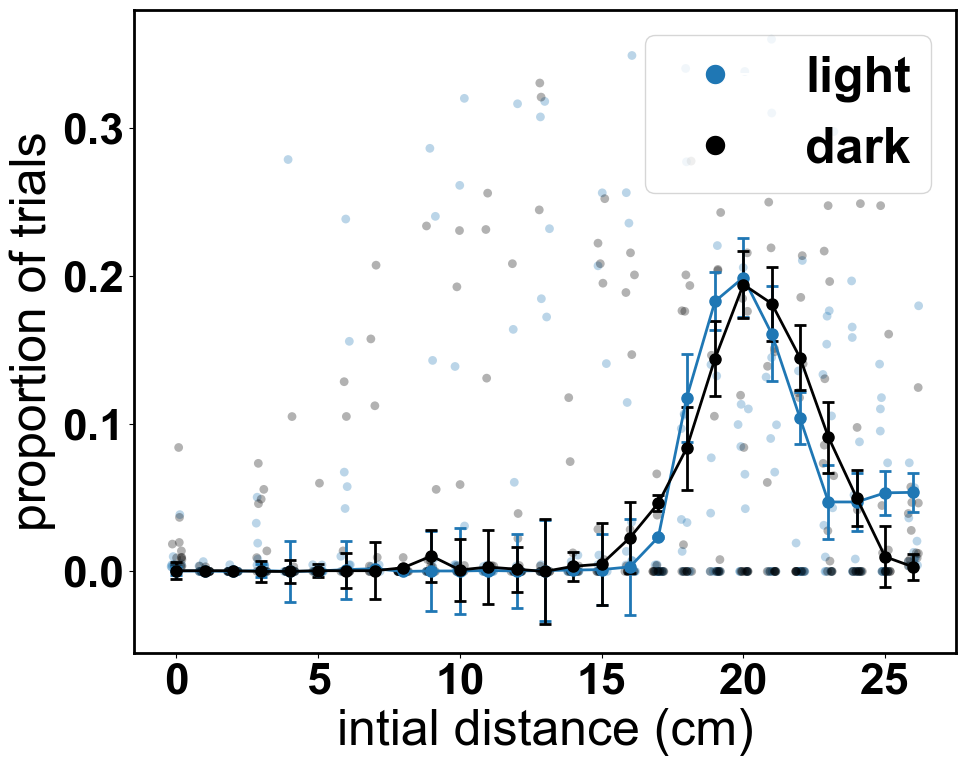

In [220]:

plt.rcParams.update({
    'font.size': 32,
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
xnew = np.arange(0, 27, 1)
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'intial_distance')
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (no bold)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
light_dist = (light.intial_distance.to_numpy())
light_dist = light_dist[np.where((light_dist >= 0))]
light_dist = light_dist[np.where((light_dist <= 27))]

light_counts, light_bins = np.histogram(light_dist, bins=27)
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.intial_distance.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists >= 0))]
    ani_light_dists = ani_light_dists[np.where((ani_light_dists <= 27))]
  
    counts, bins = np.histogram(ani_light_dists, bins=27)
    prob = counts / sum(counts)
    light_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
light_sd = np.nanstd(light_prob, axis=0)/np.sqrt(np.sum(~np.isnan(light_prob), axis=0))

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = (dark.intial_distance.to_numpy())
dark_dist = dark_dist[np.where((dark_dist >= 0))]
dark_dist = dark_dist[np.where((dark_dist <= 27))]

dark_counts, dark_bins = np.histogram(dark_dist, bins=27)
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.intial_distance.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists >= 0))]
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists <= 27))]
   
    counts, bins = np.histogram(ani_dark_dists, bins=27)
    prob = counts / sum(counts)
    dark_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
dark_sd = np.nanstd(dark_prob, axis=0)/ np.sqrt(np.sum(~np.isnan(dark_prob), axis=0))

# Plot individual points
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars
ax.errorbar(xnew, light_hist, yerr=light_sd,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_hist, yerr=dark_sd,
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting



ax.set_ylabel('proportion of trials', fontsize=36)  # lowercase
ax.set_xlabel('intial distance (cm)', fontsize=36)  # lowercase
# Formatting

#ax.set_xticks([0, -5,0, 5,10])



# Add grid lines


# Legend (lowercase labels)
ax.legend(loc='upper right', fontsize=36, framealpha=0.8)

# Create custom legend handles
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=15)
]

# Legend with matching style
# Update your legend call
ax.legend(handles=legend_handles, loc='upper right', fontsize=36, framealpha=0.8)

plt.tight_layout()

In [222]:
dark_bins

array([ 2.        ,  2.92592593,  3.85185185,  4.77777778,  5.7037037 ,
        6.62962963,  7.55555556,  8.48148148,  9.40740741, 10.33333333,
       11.25925926, 12.18518519, 13.11111111, 14.03703704, 14.96296296,
       15.88888889, 16.81481481, 17.74074074, 18.66666667, 19.59259259,
       20.51851852, 21.44444444, 22.37037037, 23.2962963 , 24.22222222,
       25.14814815, 26.07407407, 27.        ])

In [221]:
light_bins

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
       26., 27.])

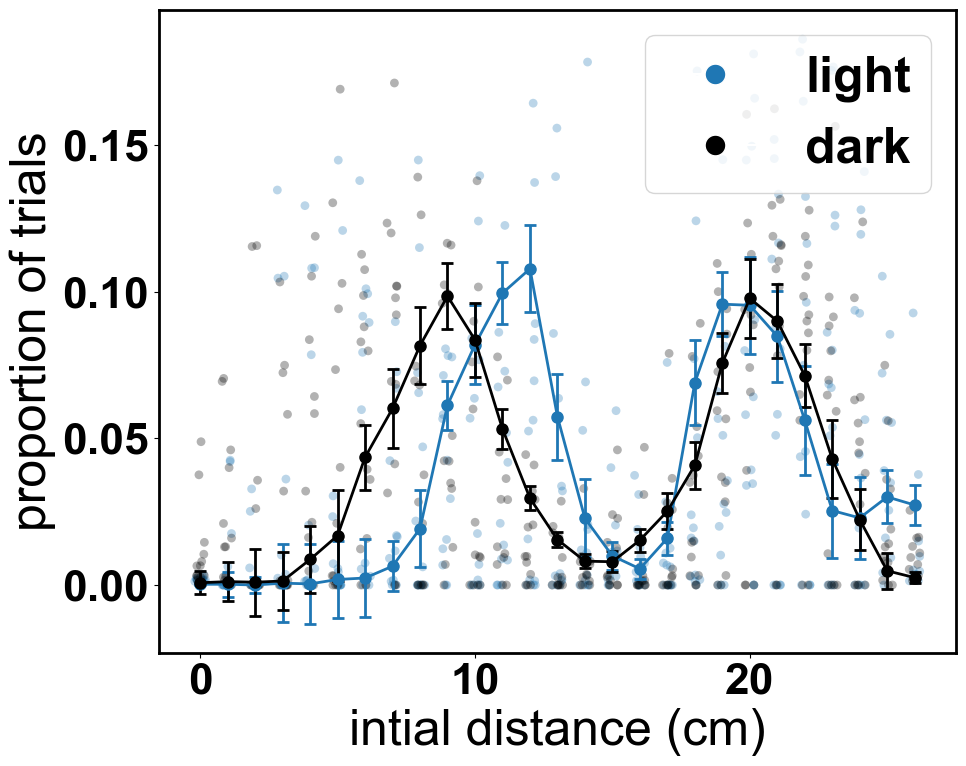

In [224]:

plt.rcParams.update({
    'font.size': 32,
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
xnew = np.arange(0, 27, 1)
data = pd.concat([joint])
data = drop_nans_in_columns(data,'intial_distance')
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (no bold)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
light_dist = (light.intial_distance.to_numpy())
light_dist = light_dist[np.where((light_dist >= 0))]
light_dist = light_dist[np.where((light_dist <= 27))]

light_counts, light_bins = np.histogram(light_dist, bins=27)
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.intial_distance.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists >= 0))]
    ani_light_dists = ani_light_dists[np.where((ani_light_dists <= 27))]
  
    counts, light_bins = np.histogram(ani_light_dists, bins=27)
    prob = counts / sum(counts)
    light_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
light_sd = np.nanstd(light_prob, axis=0)/np.sqrt(np.sum(~np.isnan(light_prob), axis=0))

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = (dark.intial_distance.to_numpy())
dark_dist = dark_dist[np.where((dark_dist >= 0))]
dark_dist = dark_dist[np.where((dark_dist <= 27))]

dark_counts, dark_bins = np.histogram(dark_dist, bins=27)
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.intial_distance.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists >= 0))]
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists <= 27))]
   
    counts, dark_bins = np.histogram(ani_dark_dists, bins=27)
    prob = counts / sum(counts)
    dark_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
dark_sd = np.nanstd(dark_prob, axis=0)/ np.sqrt(np.sum(~np.isnan(dark_prob), axis=0))

# Plot individual points
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars
ax.errorbar(xnew, light_hist, yerr=light_sd,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_hist, yerr=dark_sd,
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting



ax.set_ylabel('proportion of trials', fontsize=36)  # lowercase
ax.set_xlabel('intial distance (cm)', fontsize=36)  # lowercase
# Formatting

#ax.set_xticks([0, -5,0, 5,10])



# Add grid lines


# Legend (lowercase labels)
ax.legend(loc='upper right', fontsize=36, framealpha=0.8)

# Create custom legend handles
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=15)
]

# Legend with matching style
# Update your legend call
ax.legend(handles=legend_handles, loc='upper right', fontsize=36, framealpha=0.8)

plt.tight_layout()

In [223]:
bins

array([12.        , 12.55555556, 13.11111111, 13.66666667, 14.22222222,
       14.77777778, 15.33333333, 15.88888889, 16.44444444, 17.        ,
       17.55555556, 18.11111111, 18.66666667, 19.22222222, 19.77777778,
       20.33333333, 20.88888889, 21.44444444, 22.        , 22.55555556,
       23.11111111, 23.66666667, 24.22222222, 24.77777778, 25.33333333,
       25.88888889, 26.44444444, 27.        ])

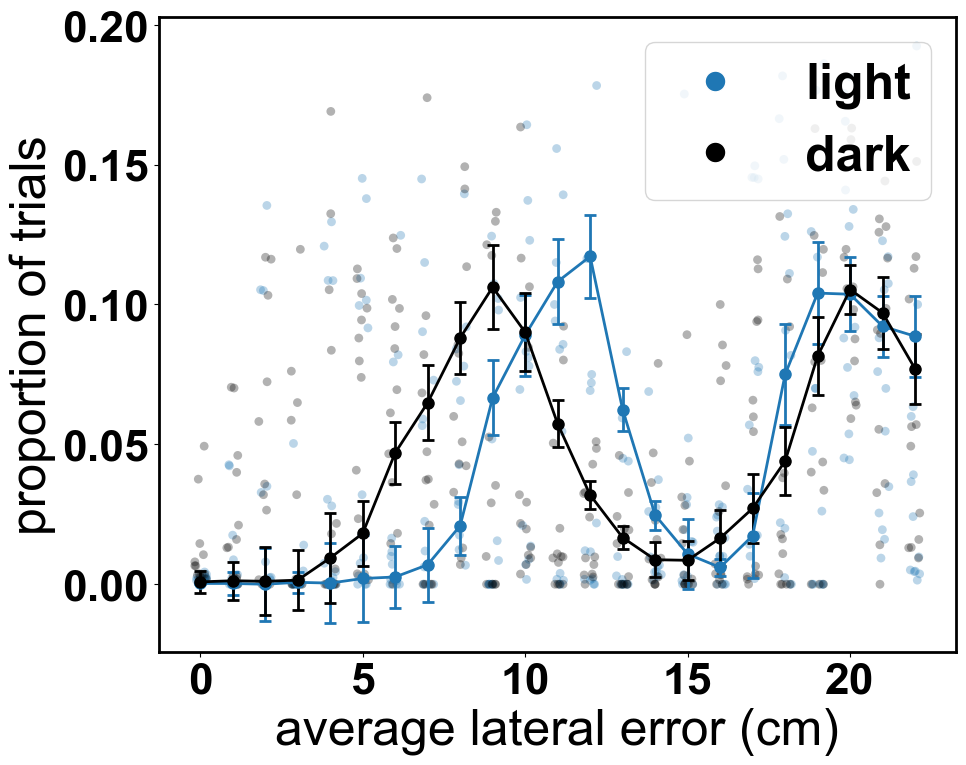

In [213]:

plt.rcParams.update({
    'font.size': 32,
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
xnew = np.arange(0, 23, 1)
data = pd.concat([joint])
data = drop_nans_in_columns(data,'intial_distance')
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (no bold)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
light_dist = (light.intial_distance.to_numpy())
light_dist = light_dist[np.where((light_dist >= 0))]
light_dist = light_dist[np.where((light_dist <= 23))]

light_counts, light_bins = np.histogram(light_dist, bins=23)
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.intial_distance.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists >= 0))]
    ani_light_dists = ani_light_dists[np.where((ani_light_dists <= 23))]
  
    counts, bins = np.histogram(ani_light_dists, bins=23)
    prob = counts / sum(counts)
    light_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
light_sd = np.nanstd(light_prob, axis=0)/np.sqrt(np.sum(~np.isnan(light_prob), axis=0))

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = (dark.intial_distance.to_numpy())
dark_dist = dark_dist[np.where((dark_dist >= 0))]
dark_dist = dark_dist[np.where((dark_dist <= 23))]

dark_counts, dark_bins = np.histogram(dark_dist, bins=23)
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.intial_distance.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists >= 0))]
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists <= 23))]
   
    counts, bins = np.histogram(ani_dark_dists, bins=23)
    prob = counts / sum(counts)
    dark_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
dark_sd = np.nanstd(dark_prob, axis=0)/ np.sqrt(np.sum(~np.isnan(dark_prob), axis=0))

# Plot individual points
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars
ax.errorbar(xnew, light_hist, yerr=light_sd,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_hist, yerr=dark_sd,
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting



ax.set_ylabel('proportion of trials', fontsize=36)  # lowercase
ax.set_xlabel('average lateral error (cm)', fontsize=36)  # lowercase
# Formatting

#ax.set_xticks([0, -5,0, 5,10])



# Add grid lines


# Legend (lowercase labels)
ax.legend(loc='upper right', fontsize=36, framealpha=0.8)

# Create custom legend handles
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=15)
]

# Legend with matching style
# Update your legend call
ax.legend(handles=legend_handles, loc='upper right', fontsize=36, framealpha=0.8)

plt.tight_layout()

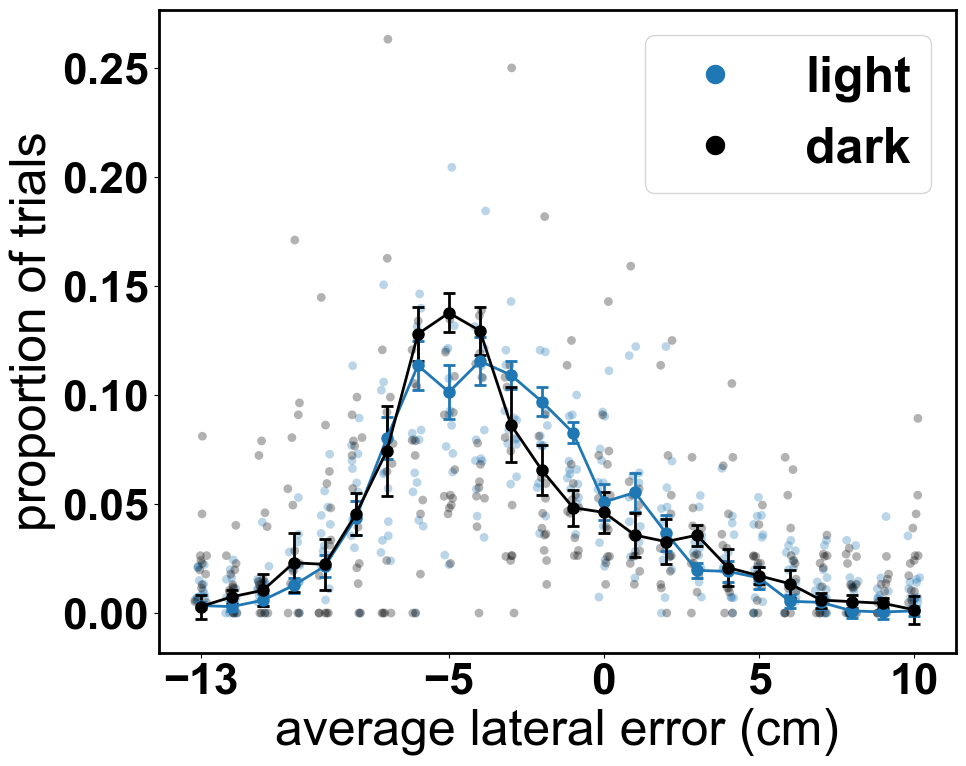

In [194]:

plt.rcParams.update({
    'font.size': 32,
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
xnew = np.arange(-13, 11, 1)
data = pd.concat([long])
data = drop_nans_in_columns(data,'avg_lateral_error')
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (no bold)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
light_dist = (light.avg_lateral_error.to_numpy())
light_dist = light_dist[np.where((light_dist >= -13))]

light_counts, light_bins = np.histogram(light_dist, bins=24)
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.avg_lateral_error.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists >= -13))]
  
    counts, bins = np.histogram(ani_light_dists, bins=24)
    prob = counts / sum(counts)
    light_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
light_sd = np.nanstd(light_prob, axis=0)/np.sqrt(np.sum(~np.isnan(light_prob), axis=0))

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = (dark.avg_lateral_error.to_numpy())
dark_dist = dark_dist[np.where((dark_dist >= -13))]

dark_counts, dark_bins = np.histogram(dark_dist, bins=24)
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.avg_lateral_error.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists >= -13))]
   
    counts, bins = np.histogram(ani_dark_dists, bins=24)
    prob = counts / sum(counts)
    dark_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
dark_sd = np.nanstd(dark_prob, axis=0)/ np.sqrt(np.sum(~np.isnan(dark_prob), axis=0))

# Plot individual points
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars
ax.errorbar(xnew, light_hist, yerr=light_sd,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_hist, yerr=dark_sd,
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting



ax.set_ylabel('proportion of trials', fontsize=36)  # lowercase
ax.set_xlabel('average lateral error (cm)', fontsize=36)  # lowercase
# Formatting

ax.set_xticks([-13, -5,0, 5,10])



# Add grid lines


# Legend (lowercase labels)
ax.legend(loc='upper right', fontsize=36, framealpha=0.8)

# Create custom legend handles
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=15)
]

# Legend with matching style
# Update your legend call
ax.legend(handles=legend_handles, loc='upper right', fontsize=36, framealpha=0.8)

plt.tight_layout()

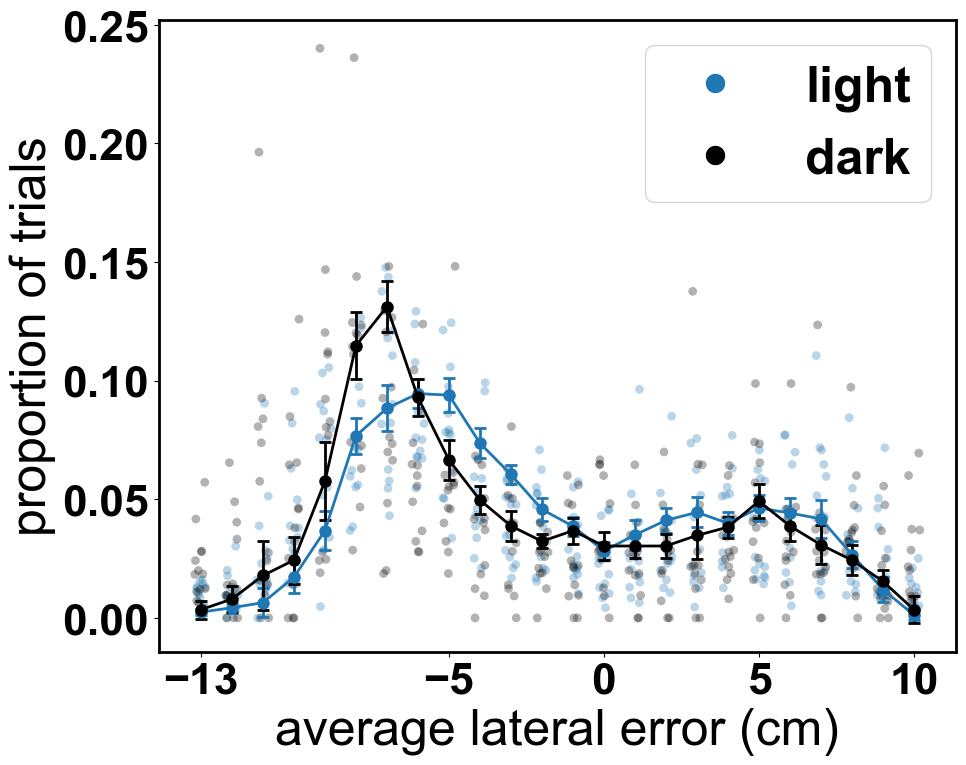

In [191]:

plt.rcParams.update({
    'font.size': 32,
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
xnew = np.arange(-13, 11, 1)
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'avg_lateral_error')
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (no bold)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
light_dist = (light.avg_lateral_error.to_numpy())
light_dist = light_dist[np.where((light_dist >= -13))]

light_counts, light_bins = np.histogram(light_dist, bins=24)
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.avg_lateral_error.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists >= -13))]
  
    counts, bins = np.histogram(ani_light_dists, bins=24)
    prob = counts / sum(counts)
    light_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
light_sd = np.nanstd(light_prob, axis=0)/np.sqrt(np.sum(~np.isnan(light_prob), axis=0))

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = (dark.avg_lateral_error.to_numpy())
dark_dist = dark_dist[np.where((dark_dist >= -13))]

dark_counts, dark_bins = np.histogram(dark_dist, bins=24)
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.avg_lateral_error.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists >= -13))]
   
    counts, bins = np.histogram(ani_dark_dists, bins=24)
    prob = counts / sum(counts)
    dark_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
dark_sd = np.nanstd(dark_prob, axis=0)/ np.sqrt(np.sum(~np.isnan(dark_prob), axis=0))

# Plot individual points
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars
ax.errorbar(xnew, light_hist, yerr=light_sd,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_hist, yerr=dark_sd,
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting



ax.set_ylabel('proportion of trials', fontsize=36)  # lowercase
ax.set_xlabel('average lateral error (cm)', fontsize=36)  # lowercase
# Formatting

ax.set_xticks([-13, -5,0, 5,10])



# Add grid lines


# Legend (lowercase labels)
ax.legend(loc='upper right', fontsize=36, framealpha=0.8)

# Create custom legend handles
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=15)
]

# Legend with matching style
# Update your legend call
ax.legend(handles=legend_handles, loc='upper right', fontsize=36, framealpha=0.8)

plt.tight_layout()

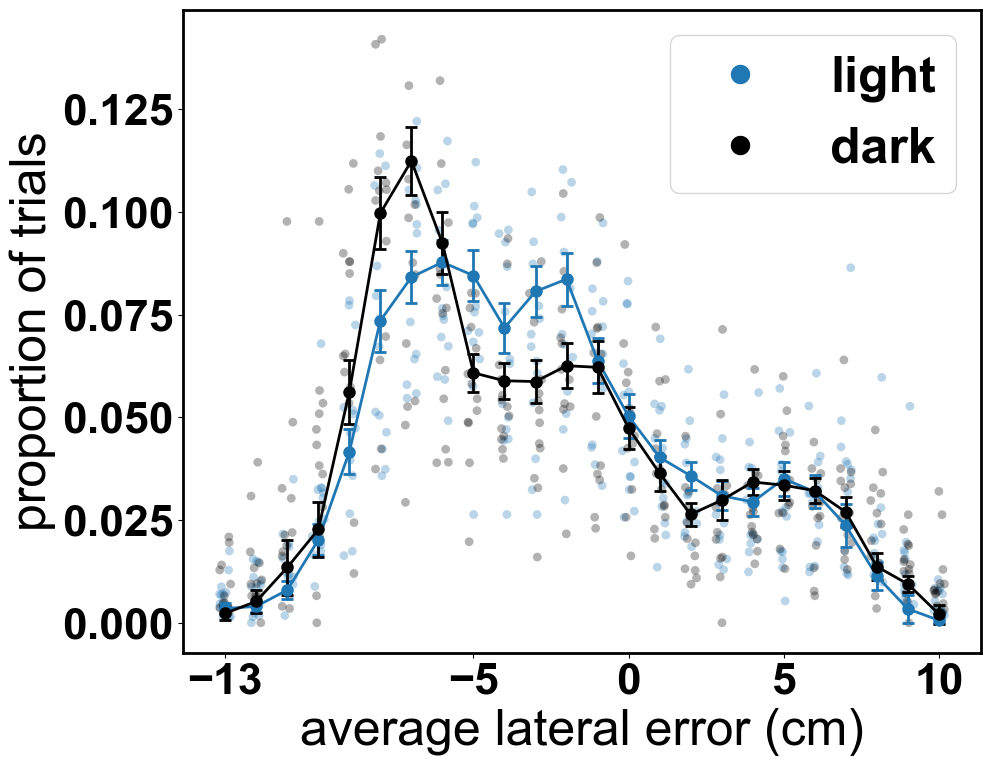

In [182]:

plt.rcParams.update({
    'font.size': 32,
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
xnew = np.arange(-13, 11, 1)
data = pd.concat([joint])
data = drop_nans_in_columns(data,'avg_lateral_error')
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (no bold)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
light_dist = (light.avg_lateral_error.to_numpy())
light_dist = light_dist[np.where((light_dist >= -13))]

light_counts, light_bins = np.histogram(light_dist, bins=24)
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.avg_lateral_error.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists >= -13))]
  
    counts, bins = np.histogram(ani_light_dists, bins=24)
    prob = counts / sum(counts)
    light_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
light_sd = np.nanstd(light_prob, axis=0)/np.sqrt(np.sum(~np.isnan(light_prob), axis=0))

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = (dark.avg_lateral_error.to_numpy())
dark_dist = dark_dist[np.where((dark_dist >= -13))]

dark_counts, dark_bins = np.histogram(dark_dist, bins=24)
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.avg_lateral_error.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists >= -13))]
   
    counts, bins = np.histogram(ani_dark_dists, bins=24)
    prob = counts / sum(counts)
    dark_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
dark_sd = np.nanstd(dark_prob, axis=0)/ np.sqrt(np.sum(~np.isnan(dark_prob), axis=0))

# Plot individual points
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars
ax.errorbar(xnew, light_hist, yerr=light_sd,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_hist, yerr=dark_sd,
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting



ax.set_ylabel('proportion of trials', fontsize=36)  # lowercase
ax.set_xlabel('average lateral error (cm)', fontsize=36)  # lowercase
# Formatting

ax.set_xticks([-13, -5,0, 5,10])



# Add grid lines


# Legend (lowercase labels)
ax.legend(loc='upper right', fontsize=36, framealpha=0.8)

# Create custom legend handles
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=15)
]

# Legend with matching style
# Update your legend call
ax.legend(handles=legend_handles, loc='upper right', fontsize=36, framealpha=0.8)

plt.tight_layout()

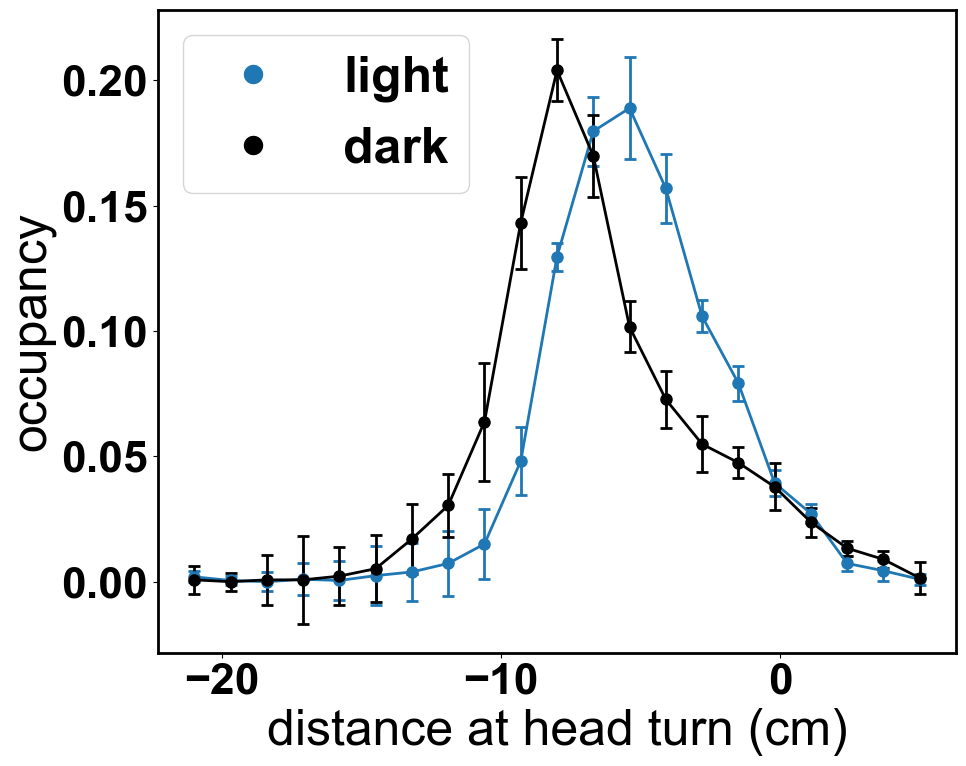

In [153]:

plt.rcParams.update({
    'font.size': 32,
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
xnew = np.arange(-21, 6, 1.3)
data = pd.concat([long])
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (no bold)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
light_dist = (light.avg_lateral_error.to_numpy())

light_counts, light_bins = np.histogram(light_dist, bins=21)
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.avg_lateral_error.to_numpy())
  
    counts, bins = np.histogram(ani_light_dists, bins=21)
    prob = counts / sum(counts)
    light_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
light_sd = np.nanstd(light_prob, axis=0)/np.sqrt(np.sum(~np.isnan(light_prob), axis=0))

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = (dark.avg_lateral_error.to_numpy())

dark_counts, dark_bins = np.histogram(dark_dist, bins=21)
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.avg_lateral_error.to_numpy())
   
    counts, bins = np.histogram(ani_dark_dists, bins=21)
    prob = counts / sum(counts)
    dark_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
dark_sd = np.nanstd(dark_prob, axis=0)/ np.sqrt(np.sum(~np.isnan(dark_prob), axis=0))

# Plot individual points
#for x_jittered, y in light_scatter:
#    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
#for x_jittered, y in dark_scatter:
#    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars
ax.errorbar(xnew, light_hist, yerr=light_sd,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_hist, yerr=dark_sd,
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting



ax.set_ylabel('occupancy', fontsize=36)  # lowercase
ax.set_xlabel('distance at head turn (cm)', fontsize=36)  # lowercase



# Add grid lines


# Legend (lowercase labels)
ax.legend(loc='upper right', fontsize=36, framealpha=0.8)

# Create custom legend handles
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=15)
]

# Legend with matching style
# Update your legend call
ax.legend(handles=legend_handles, loc='upper left', fontsize=36, framealpha=0.8)

plt.tight_layout()

In [180]:
light_bins

array([ 0.0910219 ,  1.03762162,  1.98422134,  2.93082107,  3.87742079,
        4.82402051,  5.77062023,  6.71721996,  7.66381968,  8.6104194 ,
        9.55701913, 10.50361885, 11.45021857, 12.39681829, 13.34341802,
       14.29001774, 15.23661746, 16.18321719, 17.12981691, 18.07641663,
       19.02301635, 19.96961608])

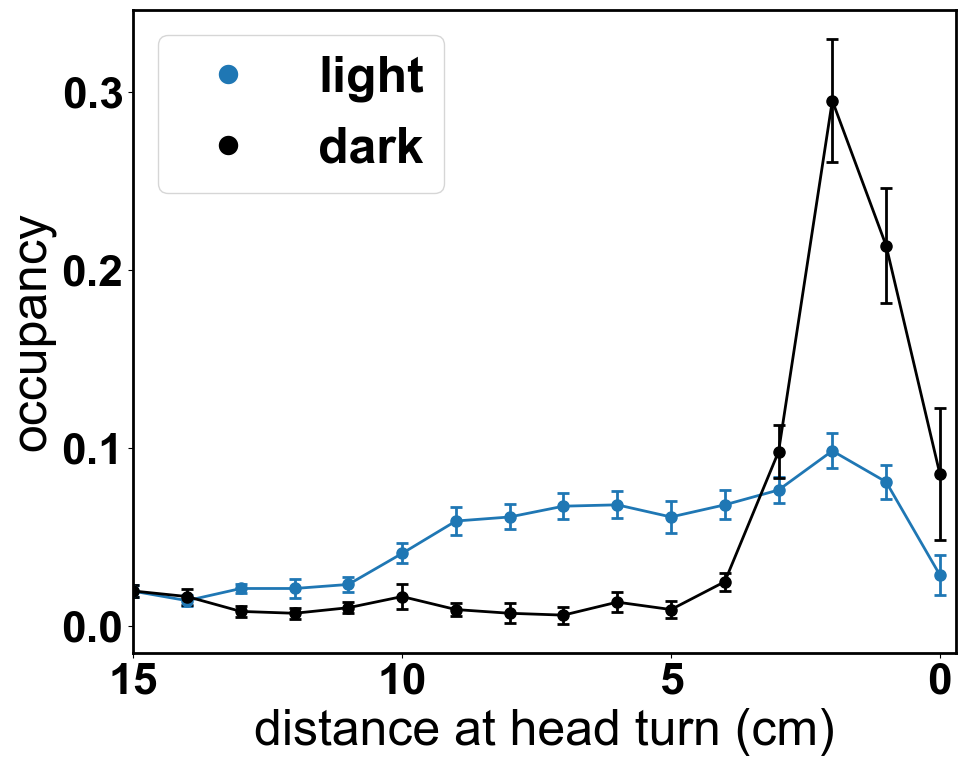

meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


In [179]:

plt.rcParams.update({
    'font.size': 32,
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
xnew = np.arange(0, 21, 1)
data = pd.concat([long])
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (no bold)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
light_dist = (light.distance_at_head_turn.to_numpy())
light_dist = light_dist[np.where((light_dist >= 0))]
light_dist = light_dist[np.where((light_dist <= 20))]
light_counts, light_bins = np.histogram(light_dist, bins=21)
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.distance_at_head_turn.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists >= 0))]
    ani_light_dists = ani_light_dists[np.where((ani_light_dists <= 20))]
    counts, bins = np.histogram(ani_light_dists, bins=21)
    prob = counts / sum(counts)
    light_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
light_sd = np.nanstd(light_prob, axis=0)/np.sqrt(np.sum(~np.isnan(light_prob), axis=0))

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = (dark.distance_at_head_turn.to_numpy())
dark_dist = dark_dist[np.where((dark_dist >= 0))]
dark_dist = dark_dist[np.where((dark_dist <= 20))]
dark_counts, dark_bins = np.histogram(dark_dist, bins=21)
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.distance_at_head_turn.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists >= 0))]
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists <= 20))]
    counts, bins = np.histogram(ani_dark_dists, bins=21)
    prob = counts / sum(counts)
    dark_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
dark_sd = np.nanstd(dark_prob, axis=0)/ np.sqrt(np.sum(~np.isnan(dark_prob), axis=0))

# Plot individual points
#for x_jittered, y in light_scatter:
#    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
#for x_jittered, y in dark_scatter:
#    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars
ax.errorbar(xnew, light_hist, yerr=light_sd,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_hist, yerr=dark_sd,
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting

ax.set_xticks([15, 10, 5, 0])
ax.set_yticks([0,.1,.2,.3])

ax.set_ylabel('occupancy', fontsize=36)  # lowercase
ax.set_xlabel('distance at head turn (cm)', fontsize=36)  # lowercase
ax.invert_xaxis()
ax.set_xlim(15,-.3)

# Add grid lines


# Legend (lowercase labels)
ax.legend(loc='upper right', fontsize=36, framealpha=0.8)

# Create custom legend handles
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=15)
]

# Legend with matching style
# Update your legend call
ax.legend(handles=legend_handles, loc='upper left', fontsize=36, framealpha=0.8)

plt.tight_layout()
plt.show()

fig.savefig(r"D:\obstacle_avoidance\figures\SC_grant\distance_at_headturn.pdf",dpi = 300, transparent=True)

In [25]:
oa = long[long.task == 'oa']
oadark = long[long.task == 'oadark']

light_ang_vel = flatten_list_of_arrays(oa.head_angle_velocity_whole_trial.to_numpy())
dark_ang_vel = flatten_list_of_arrays(oadark.head_angle_velocity_whole_trial.to_numpy())

(array([0.0009004 , 0.00180588, 0.00256554, 0.00300302, 0.00292671,
        0.00210432, 0.00157018, 0.00095805, 0.00055957, 0.000273  ]),
 array([  0.,  60., 120., 180., 240., 300., 360., 420., 480., 540., 600.]),
 <BarContainer object of 10 artists>)

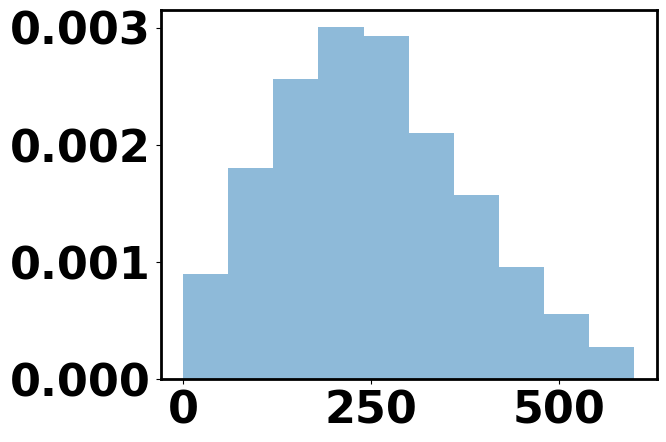

In [97]:

plt.rcParams.update({
    'font.size': 32,
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
light_ang_vel_abs = np.abs(light_ang_vel*60) 
peaks, prop = find_peaks(light_ang_vel_abs,height=(1),width=2,distance=15)
plt.hist(light_ang_vel_abs[peaks],range=(0,600),density=True,alpha=.5,bins=10,color='tab:blue')
#plt.savefig(r"D:\obstacle_avoidance\figures\SC_grant\histogram_headturn.pdf",dpi = 300, transparent=True)

In [100]:
sum(np.isnan(light_ang_vel_abs))

0

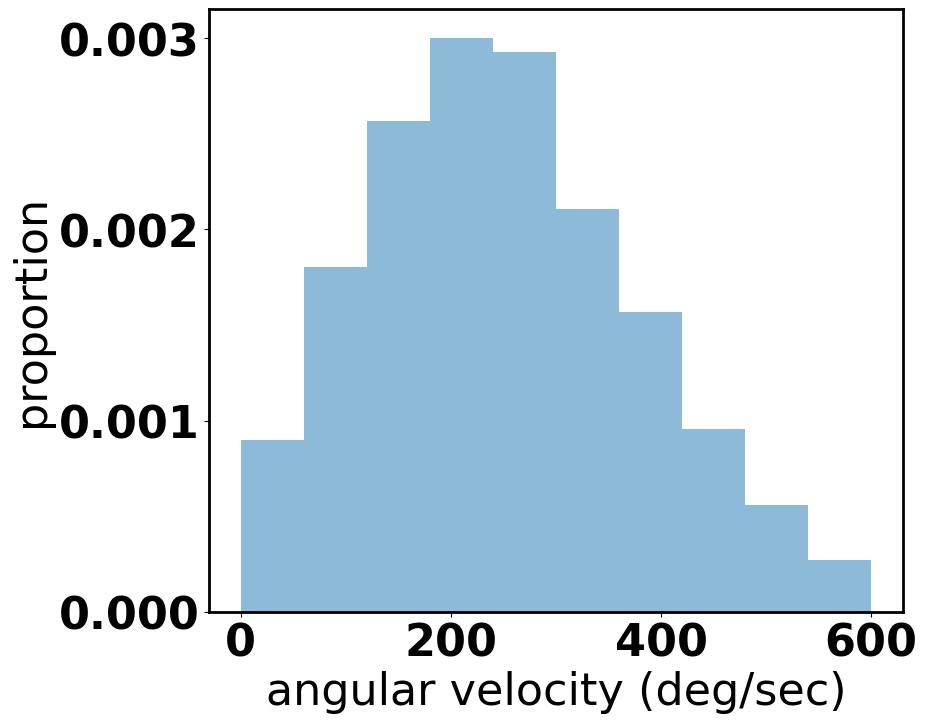

In [98]:
plt.rcParams.update({
    'font.size': 32,
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Create figure with size 10,8
plt.figure(figsize=(10, 8))

light_ang_vel_abs = np.abs(light_ang_vel*60) 
peaks, prop = find_peaks(light_ang_vel_abs, height=(1), width=2, distance=15)

# Create histogram
plt.hist(light_ang_vel_abs[peaks], range=(0,600), density=True, alpha=.5, bins=10, color='tab:blue')

# Set labels
plt.xlabel('angular velocity (deg/sec)')
plt.ylabel('proportion')

# Set y-ticks
#plt.yticks([0, 0.001,.002, 0.003])

# Show plot
plt.tight_layout()  # Ensures labels fit properly
plt.savefig(r"D:\obstacle_avoidance\figures\SC_grant\histogram_headturn.pdf",dpi = 300, transparent=True)
plt.show()


Integral of the histogram (should be ~1): 1.0000


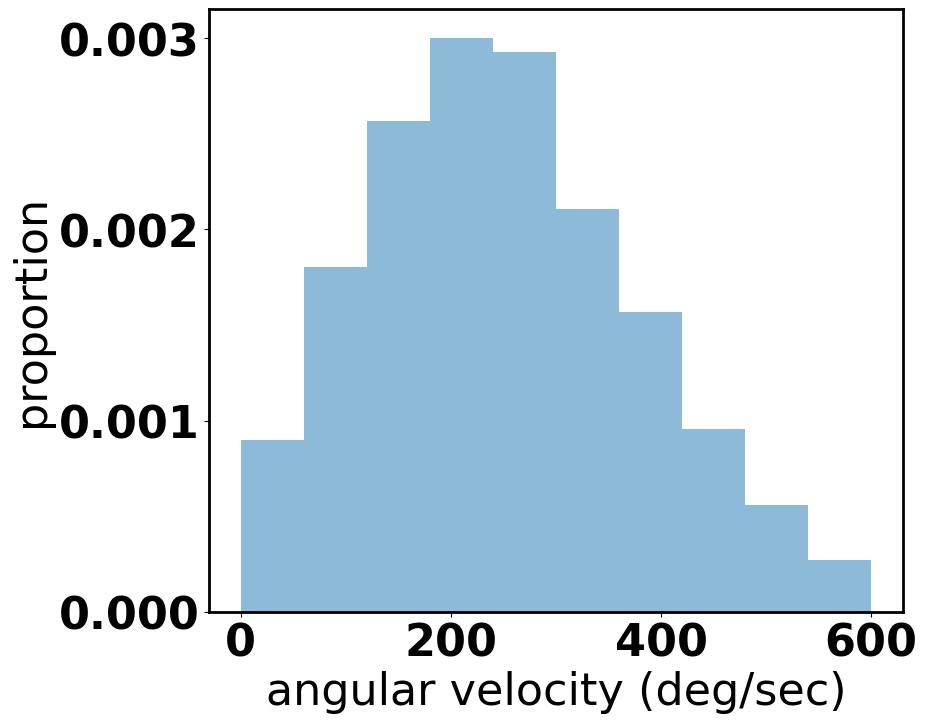

In [101]:
plt.rcParams.update({
    'font.size': 32,
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Create figure with size 10,8
plt.figure(figsize=(10, 8))

light_ang_vel_abs = np.abs(light_ang_vel*60) 
peaks, prop = find_peaks(light_ang_vel_abs, height=(1), width=2, distance=15)

# Create histogram and get bin counts and edges
counts, bin_edges, _ = plt.hist(light_ang_vel_abs[peaks], range=(0,600), density=True, alpha=.5, bins=10, color='tab:blue')

# Calculate the integral (should be ~1 if density=True is working)
bin_widths = np.diff(bin_edges)
hist_integral = np.sum(counts * bin_widths)
print(f"Integral of the histogram (should be ~1): {hist_integral:.4f}")

# Set labels
plt.xlabel('angular velocity (deg/sec)')
plt.ylabel('proportion')

# Show plot
plt.tight_layout()
plt.savefig('angular_velocity_histogram.pdf', bbox_inches='tight')  # Save as PDF
plt.show()
    

In [102]:
bin_widths = np.diff(bin_edges)
hist_integral = np.sum(counts * bin_widths)

In [103]:
hist_integral

0.9999999999999999

In [24]:
light_ang_vel_abs[peaks].shape

(16796,)

(array([   0.,    0., 1692., 3216., 2710., 2266., 1815., 1274.,  952.,
         752.]),
 array([  0.,  40.,  80., 120., 160., 200., 240., 280., 320., 360., 400.]),
 <BarContainer object of 10 artists>)

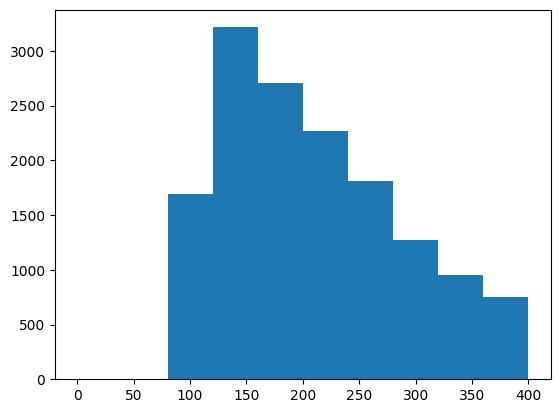

In [23]:
plt.hist(light_ang_vel_abs[peaks],range=(0,400))

In [83]:
light_trial_permin = pd.read_hdf(r"D:\obstacle_avoidance\metadata\SFN\data\light_trial_permin.h5")

In [106]:
light_trial_permin

,animal,date,date_index,trialpermin,task,session_min,trials,trial_time
0,J701LT,030624,0.0,9.920298,oa,13.104444,130,5.250000
1,J701NN,030624,0.0,12.901412,oa,11.859167,153,4.100000
2,J701RN,030624,0.0,8.695864,oa,11.384722,99,5.616667
3,J701RT,030624,0.0,12.540078,oa,7.017500,88,4.266667
4,J701LT,030724,1.0,11.715976,oa,7.511111,88,4.400000
...,...,...,...,...,...,...,...,...
15,G8CK1TT,051523,-2.0,9.664594,oa,8.174167,79,4.350000
16,G8CK1LN,051623,-1.0,14.393968,oa,7.294722,105,2.966667
17,G8CK1LT,051623,-1.0,10.989886,oa,10.464167,115,3.483333
18,G8CK1RT,051623,-1.0,10.432721,oa,8.435000,88,3.216667


In [111]:
light_trial_permin.groupby('date_index').trialpermin.mean()

date_index
-5.0      5.602590
-4.0      3.735111
-3.0      4.568927
-2.0      7.008148
-1.0      8.783589
 0.0     12.728398
 1.0     13.790404
 2.0     15.482562
 3.0     16.081000
 4.0     17.534221
 5.0     18.725078
 6.0     20.493719
 7.0     18.565966
 8.0     20.173000
 9.0     19.565708
 10.0    17.073460
 11.0    17.124746
 12.0    16.525275
 13.0    16.442330
 14.0    18.695152
 15.0    18.835305
Name: trialpermin, dtype: float64

In [110]:
light_trial_permin.groupby('date_index').trial_time.mean()

date_index
-5.0      8.650000
-4.0     20.810897
-3.0     13.680769
-2.0      6.461538
-1.0      4.262821
 0.0      4.151282
 1.0      3.841667
 2.0      3.329487
 3.0      3.161538
 4.0      2.917949
 5.0      2.789103
 6.0      2.564103
 7.0      2.663889
 8.0      2.583333
 9.0      2.689583
 10.0     3.164583
 11.0     3.068750
 12.0     3.093750
 13.0     3.070833
 14.0     2.783333
 15.0     2.768750
Name: trial_time, dtype: float64

In [121]:
joint.animal

0        J701LT
1        J701LT
2        J701LT
3        J701LT
4        J701LT
          ...  
14548    G8CKLN
14549    G8CKLN
14550    G8CKLN
14551    G8CKLN
14552    G8CKLN
Name: animal, Length: 14553, dtype: object

In [124]:
joint.groupby('task').animal.unique()[1]

array(['J704RT', 'J704NN', 'J704LT', 'J704LN', 'G8CK1RT', 'G8CK1LT',
       'G8CK1TT', 'G8CK1LN', 'G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN',
       'G8CKLN'], dtype=object)

In [112]:
light_trial_permin.animal.unique()

array(['J701LT', 'J701NN', 'J701RN', 'J701RT', 'G8CKLN', 'G8CKLT',
       'G8CKRN', 'G8CKRT', 'G8CKTT', 'G8CK1LN', 'G8CK1LT', 'G8CK1RT',
       'G8CK1TT'], dtype=object)

In [ ]:
light_trial_permin.groupby('animal').session_min.mean()

In [108]:
light_trial_permin.groupby('date_index').session_min.mean()

date_index
-5.0      8.917639
-4.0     15.682885
-3.0     17.336624
-2.0     17.175556
-1.0     17.199530
 0.0      8.319808
 1.0      8.364765
 2.0      7.347073
 3.0      6.654103
 4.0      6.822436
 5.0      6.258419
 6.0      7.168355
 7.0      5.745031
 8.0      6.102253
 9.0      6.233681
 10.0     7.007778
 11.0     8.173889
 12.0     5.639514
 13.0     4.928958
 14.0     4.904861
 15.0     6.180139
Name: session_min, dtype: float64

In [105]:
light_trial_permin.groupby('date_index').trials.mean()

date_index
-5.0      50.250000
-4.0      48.076923
-3.0      61.769231
-2.0     111.000000
-1.0     134.769231
 0.0     102.692308
 1.0     112.615385
 2.0     111.846154
 3.0     106.538462
 4.0     116.615385
 5.0     115.461538
 6.0     147.000000
 7.0     107.888889
 8.0     124.222222
 9.0     120.500000
 10.0    121.500000
 11.0    140.750000
 12.0     88.750000
 13.0     78.750000
 14.0     89.500000
 15.0    116.250000
Name: trials, dtype: float64

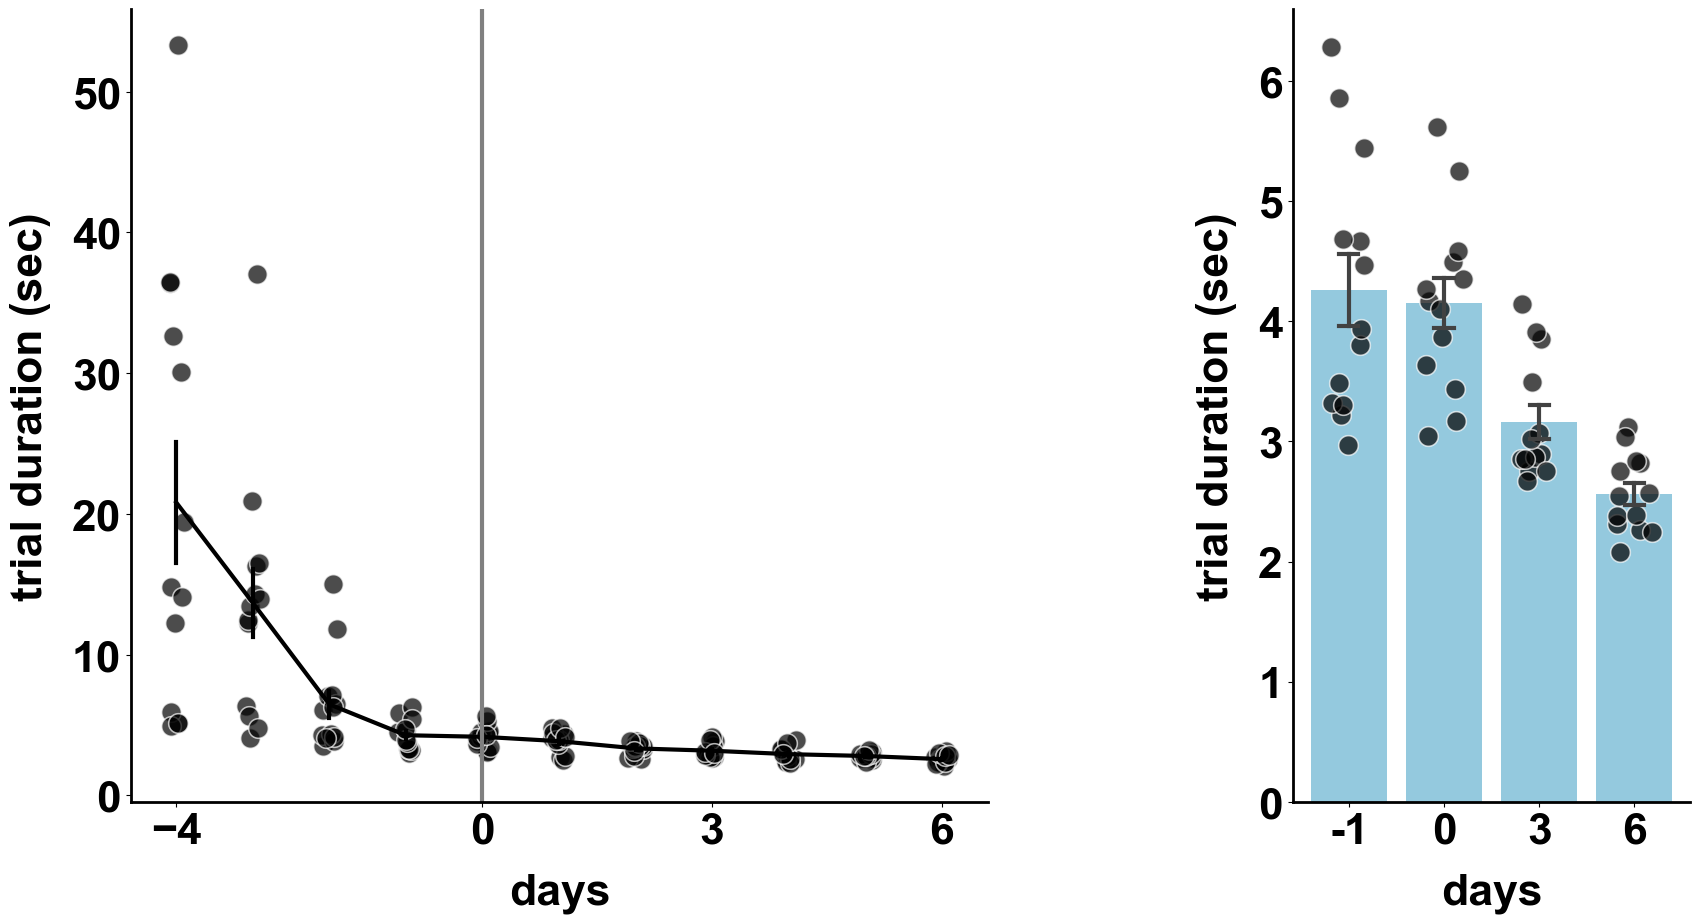

In [ ]:
# Set global font properties

plt.rcParams.update({
    'font.size': 32,
    'font.weight': 'bold',
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

line = light_trial_permin[(light_trial_permin.date_index >= -4) & (light_trial_permin.date_index <= 6)]
plt.rc('axes', edgecolor='black')

# Create larger figure
fig = plt.figure(figsize=(20, 10))

# Use GridSpec with adjusted spacing - now with more space for y-axis labels
gs = GridSpec(1, 6, figure=fig, width_ratios=[4, 0.5, 0.1, 0.1, 1.5, 0.5])  # Added more space on both sides
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 3:5], sharey=None)  # Explicitly no shared axis

# Remove top and right spines
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)

# Set labels with padding
ax1.set_xlabel('days', fontweight='bold', labelpad=15)
ax1.set_ylabel('trial duration (sec)', fontweight='bold', labelpad=15)
ax2.set_xlabel('days', fontweight='bold', labelpad=15)
ax2.set_ylabel('trial duration (sec)', fontweight='bold', labelpad=15)  # Keep y-label for second plot

# Calculate individual animal means
individual_means = line.groupby(['date_index', 'animal'])['trial_time'].mean().reset_index()
individual_means['jittered_x'] = individual_means['date_index'] + np.random.uniform(-0.1, 0.1, size=len(individual_means))

# Line plot
sns.lineplot(ax=ax1, data=line, x='date_index', y='trial_time', 
             errorbar='se', err_style='bars', color='black', 
             linewidth=3, err_kws={'linewidth': 3})
sns.scatterplot(ax=ax1, data=individual_means, x='jittered_x', y='trial_time', 
                color='black', s=200, alpha=0.7)
ax1.axvline(0, color='grey', ls='-', linewidth=3)
ax1.set_xticks([-4, 0, 3, 6])

# Bar plot data
bar = light_trial_permin[(light_trial_permin.date_index.isin([-1.0,0.0, 3.0, 6.0]))]
bar_individual_means = bar.groupby(['date_index', 'animal'])['trial_time'].mean().reset_index()

# Bar plot - now with independent y-axis
sns.barplot(ax=ax2, data=bar, x='date_index', y='trial_time', 
            errorbar='se', color='skyblue', 
            errwidth=3, linewidth=3, capsize=0.2)

# Add jittered points
date_to_pos = {-1.0:0,0.0: 1, 3.0: 2, 6.0: 3}
bar_individual_means['x_pos'] = bar_individual_means['date_index'].map(date_to_pos)
bar_individual_means['jittered_x'] = bar_individual_means['x_pos'] + np.random.uniform(-0.2, 0.2, size=len(bar_individual_means))
sns.scatterplot(ax=ax2, data=bar_individual_means, x='jittered_x', y='trial_time', 
                color='black', s=200, alpha=0.7)

# Adjust bar plot ticks
ax2.set_xticks([0, 1, 2,3])
ax2.set_xticklabels([-1,0, 3, 6])

# Make all text bold
for ax in [ax1, ax2]:
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
                 ax.get_xticklabels() + ax.get_yticklabels()):
        item.set_fontweight('bold')

# Adjust layout with even more space between plots
plt.subplots_adjust(wspace=1.0)  # Increased space between subplots
plt.tight_layout()
#fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\trial_duration.pdf',dpi = 300)

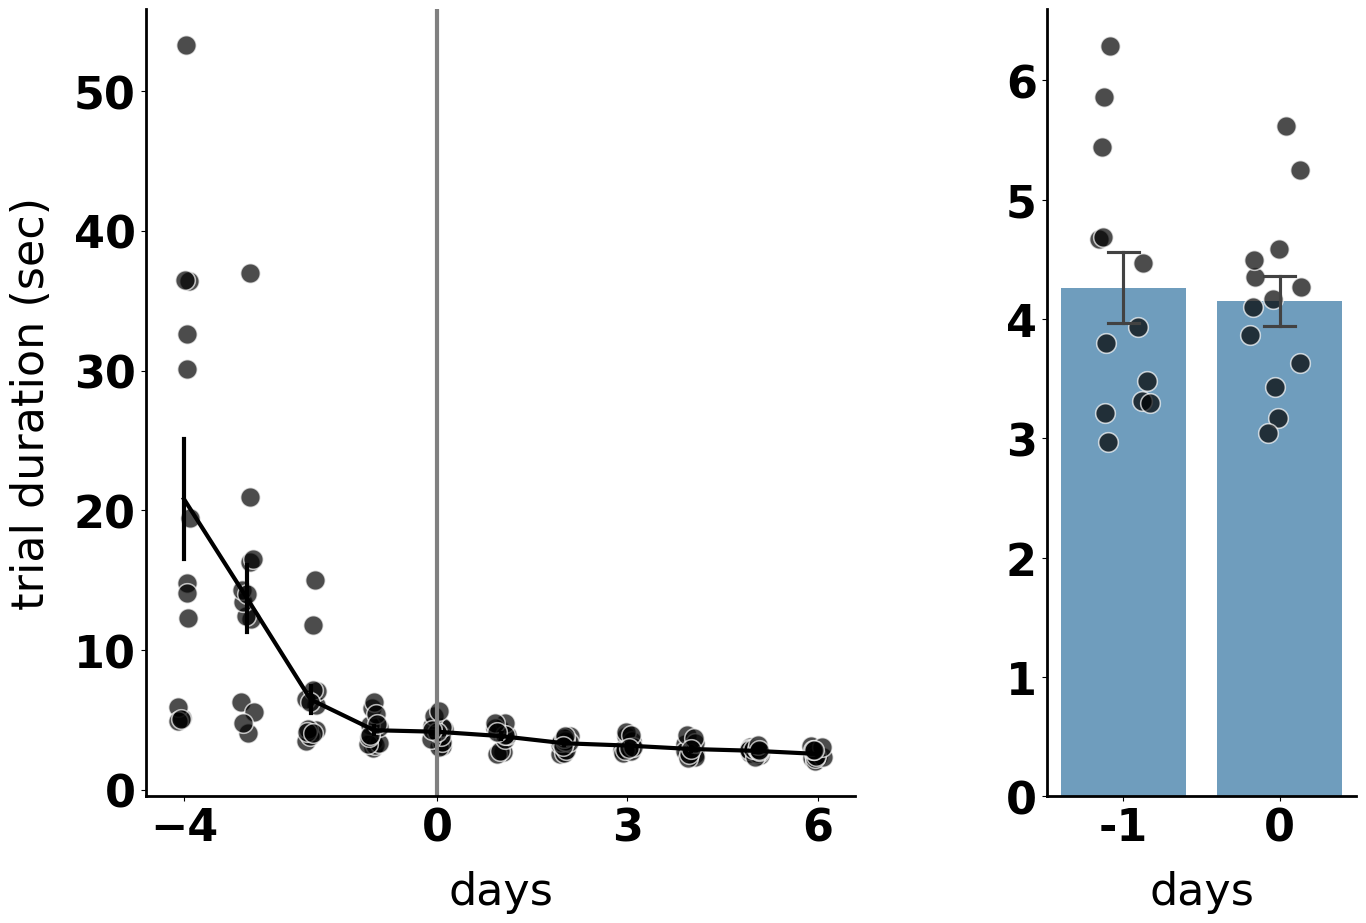

In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Set global font properties
plt.rcParams.update({
    'font.size': 32,
    'font.weight': 'bold',
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',
    'savefig.transparent': True
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Prepare data
line = light_trial_permin[(light_trial_permin.date_index >= -4) & (light_trial_permin.date_index <= 6)]
bar = light_trial_permin[light_trial_permin.date_index.isin([-1, 0])]

# Create figure
fig = plt.figure(figsize=(16, 10))
gs = GridSpec(1, 6, figure=fig, width_ratios=[4, 0.5, 0.1, 0.1, 1.5, 0.5])
ax1 = fig.add_subplot(gs[0, 0:2])  # Line plot
ax2 = fig.add_subplot(gs[0, 3:5])  # Bar plot

# Remove top and right spines
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)

# Set labels - removed ylabel for ax2
ax1.set_xlabel('days', labelpad=15)
ax1.set_ylabel('trial duration (sec)', labelpad=15)
ax2.set_xlabel('days', labelpad=15)
ax2.set_ylabel('')  # This removes the y-axis label for the second plot

# LINE PLOT (ax1)
individual_means = line.groupby(['date_index', 'animal'])['trial_time'].mean().reset_index()
individual_means['jittered_x'] = individual_means['date_index'] + np.random.uniform(-0.1, 0.1, size=len(individual_means))

sns.lineplot(ax=ax1, data=line, x='date_index', y='trial_time',
             errorbar='se', err_style='bars', color='black',
             linewidth=3, err_kws={'linewidth': 3})

sns.scatterplot(ax=ax1, data=individual_means, x='jittered_x', y='trial_time',
                color='black', s=200, alpha=0.7)

ax1.axvline(0, color='grey', ls='-', linewidth=3)
ax1.set_xticks([-4, 0, 3, 6])

# BAR PLOT (ax2)
bar_individual_means = bar.groupby(['date_index', 'animal'])['trial_time'].mean().reset_index()
date_to_pos = {-1: 0, 0: 1}
bar_individual_means['x_pos'] = bar_individual_means['date_index'].map(date_to_pos)
bar_individual_means['jittered_x'] = bar_individual_means['x_pos'] + np.random.uniform(-0.2, 0.2, size=len(bar_individual_means))

sns.barplot(ax=ax2, data=bar, x='date_index', y='trial_time',
            errorbar='se', color='tab:blue',
             linewidth=3, capsize=0.2, alpha=0.7)

sns.scatterplot(ax=ax2, data=bar_individual_means, x='jittered_x', y='trial_time',
                color='black', s=200, alpha=0.7)

ax2.set_xticks([0, 1])
ax2.set_xticklabels(['-1', '0'])
ax2.set_ylabel('')  # This removes the y-axis label for the second plot

# Adjust layout
plt.subplots_adjust(wspace=1.0)
plt.tight_layout()
plt.show()
fig.savefig(r'd:\obstacle_avoidance\figures\SC_grant\trial_duration.pdf',dpi = 300)

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Set global font properties
plt.rcParams.update({
    'font.size': 32,
    'font.weight': 'bold',
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',
    'savefig.transparent': True
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Prepare data
line = light_trial_permin[(light_trial_permin.date_index >= -4) & (light_trial_permin.date_index <= 6)]
bar = light_trial_permin[light_trial_permin.date_index.isin([-1, 0])]

# Create figure
fig = plt.figure(figsize=(16, 10))
gs = GridSpec(1, 6, figure=fig, width_ratios=[4, 0.5, 0.1, 0.1, 1.5, 0.5])
ax1 = fig.add_subplot(gs[0, 0:2])  # Line plot
ax2 = fig.add_subplot(gs[0, 3:5])  # Bar plot

# Remove top and right spines
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)

# Set labels - removed ylabel for ax2
ax1.set_xlabel('days', labelpad=15)
ax1.set_ylabel('trials', labelpad=15)  # Changed to 'trials'
ax2.set_xlabel('days', labelpad=15)
ax2.set_ylabel('')  # Removed y-axis label for second plot

# LINE PLOT (ax1)
individual_means = line.groupby(['date_index', 'animal'])['trials'].mean().reset_index()  # Changed to 'trials'
individual_means['jittered_x'] = individual_means['date_index'] + np.random.uniform(-0.1, 0.1, size=len(individual_means))

sns.lineplot(ax=ax1, data=line, x='date_index', y='trials',  # Changed to 'trials'
             errorbar='se', err_style='bars', color='black',
             linewidth=3, err_kws={'linewidth': 3})

sns.scatterplot(ax=ax1, data=individual_means, x='jittered_x', y='trials',  # Changed to 'trials'
                color='black', s=200, alpha=0.7)

ax1.axvline(0, color='grey', ls='-', linewidth=3)
ax1.set_xticks([-4, 0, 3, 6])

# BAR PLOT (ax2)
bar_individual_means = bar.groupby(['date_index', 'animal'])['trials'].mean().reset_index()  # Changed to 'trials'
date_to_pos = {-1: 0, 0: 1}
bar_individual_means['x_pos'] = bar_individual_means['date_index'].map(date_to_pos)
bar_individual_means['jittered_x'] = bar_individual_means['x_pos'] + np.random.uniform(-0.2, 0.2, size=len(bar_individual_means))

sns.barplot(ax=ax2, data=bar, x='date_index', y='trials',  # Changed to 'trials'
            errorbar='se', color='blue',
             linewidth=3, capsize=0.2)

sns.scatterplot(ax=ax2, data=bar_individual_means, x='jittered_x', y='trials',  # Changed to 'trials'
                color='black', s=200, alpha=0.7)

ax2.set_xticks([0, 1])
ax2.set_xticklabels(['-1', '0'])
ax2.set_ylabel('')  # This removes the y-axis label for the second plot

# Adjust layout
plt.subplots_adjust(wspace=1.0)
plt.tight_layout()
plt.show()

NameError: name 'light_trial_permin' is not defined

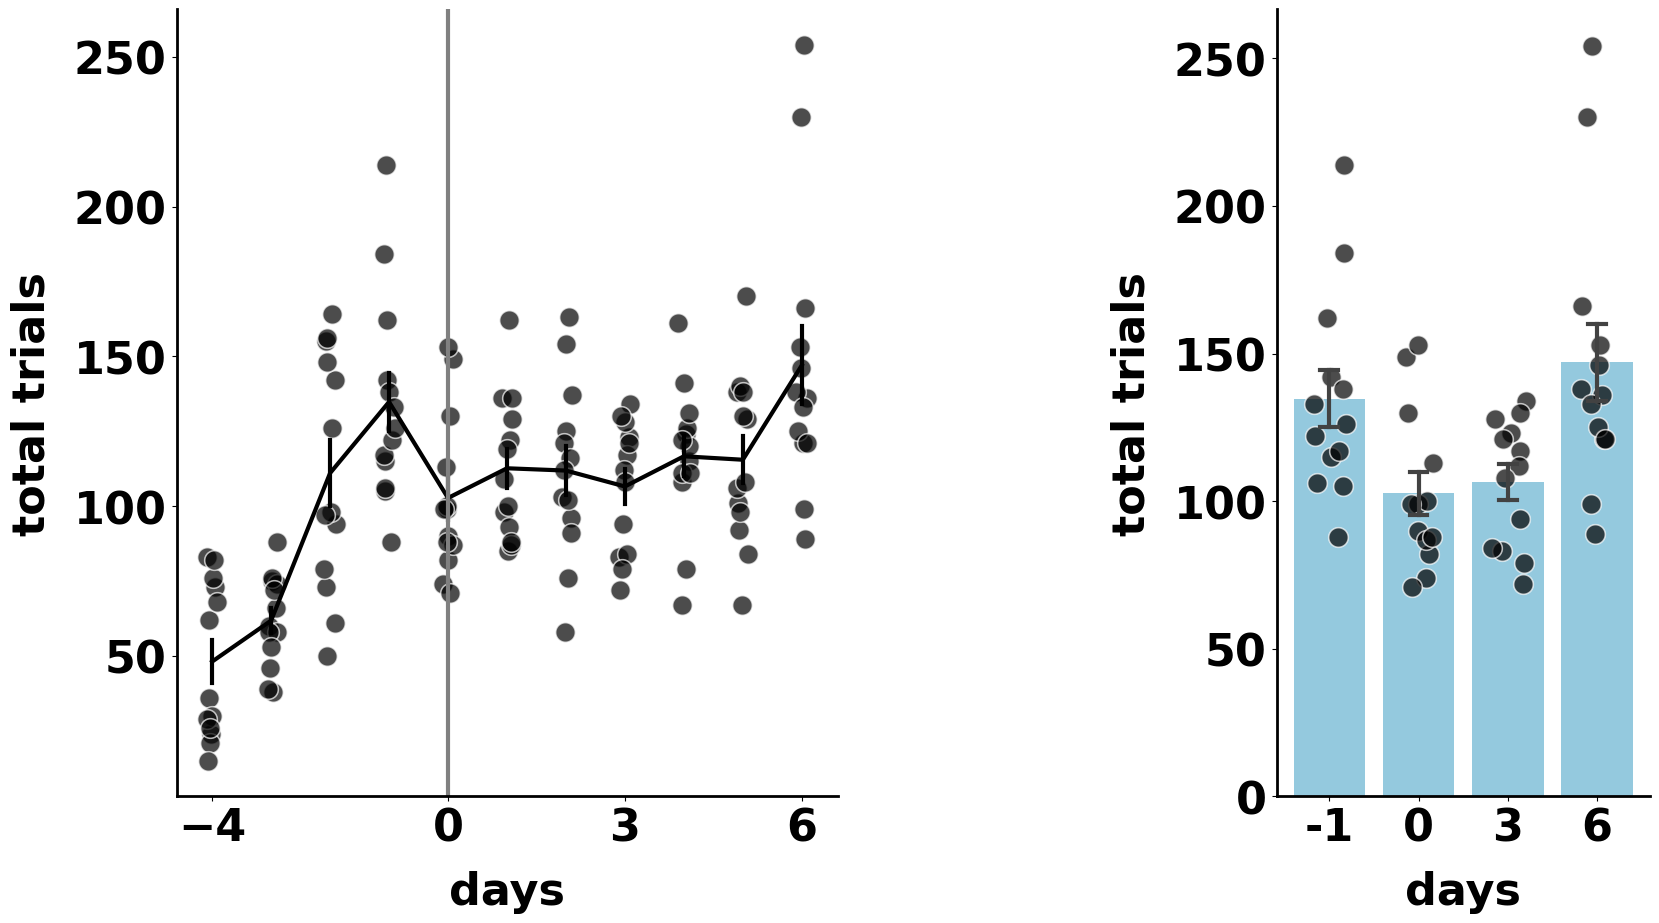

In [92]:
# Set global font properties

plt.rcParams.update({
    'font.size': 32,
    'font.weight': 'bold',
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

line = light_trial_permin[(light_trial_permin.date_index >= -4) & (light_trial_permin.date_index <= 6)]
plt.rc('axes', edgecolor='black')

# Create larger figure
fig = plt.figure(figsize=(20, 10))

# Use GridSpec with adjusted spacing - now with more space for y-axis labels
gs = GridSpec(1, 6, figure=fig, width_ratios=[4, 0.5, 0.1, 0.1, 1.5, 0.5])  # Added more space on both sides
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 3:5], sharey=None)  # Explicitly no shared axis

# Remove top and right spines
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)

# Set labels with padding
ax1.set_xlabel('days', fontweight='bold', labelpad=15)
ax1.set_ylabel('total trials', fontweight='bold', labelpad=15)
ax2.set_xlabel('days', fontweight='bold', labelpad=15)
ax2.set_ylabel('total trials', fontweight='bold', labelpad=15)  # Keep y-label for second plot

# Calculate individual animal means
individual_means = line.groupby(['date_index', 'animal'])['trials'].mean().reset_index()
individual_means['jittered_x'] = individual_means['date_index'] + np.random.uniform(-0.1, 0.1, size=len(individual_means))

# Line plot
sns.lineplot(ax=ax1, data=line, x='date_index', y='trials', 
             errorbar='se', err_style='bars', color='black', 
             linewidth=3, err_kws={'linewidth': 3})
sns.scatterplot(ax=ax1, data=individual_means, x='jittered_x', y='trials', 
                color='black', s=200, alpha=0.7)
ax1.axvline(0, color='grey', ls='-', linewidth=3)
ax1.set_xticks([-4, 0, 3, 6])

# Bar plot data
bar = light_trial_permin[(light_trial_permin.date_index.isin([-1.0,0.0, 3.0, 6.0]))]
bar_individual_means = bar.groupby(['date_index', 'animal'])['trials'].mean().reset_index()

# Bar plot - now with independent y-axis
sns.barplot(ax=ax2, data=bar, x='date_index', y='trials', 
            errorbar='se', color='skyblue', 
            errwidth=3, linewidth=3, capsize=0.2)

# Add jittered points
date_to_pos = {-1.0:0,0.0: 1, 3.0: 2, 6.0: 3}
bar_individual_means['x_pos'] = bar_individual_means['date_index'].map(date_to_pos)
bar_individual_means['jittered_x'] = bar_individual_means['x_pos'] + np.random.uniform(-0.2, 0.2, size=len(bar_individual_means))
sns.scatterplot(ax=ax2, data=bar_individual_means, x='jittered_x', y='trials', 
                color='black', s=200, alpha=0.7)

# Adjust bar plot ticks
ax2.set_xticks([0, 1, 2,3])
ax2.set_xticklabels([-1,0, 3, 6])

# Make all text bold
for ax in [ax1, ax2]:
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
                 ax.get_xticklabels() + ax.get_yticklabels()):
        item.set_fontweight('bold')

# Adjust layout with even more space between plots
plt.subplots_adjust(wspace=1.0)  # Increased space between subplots
plt.tight_layout()
fig.savefig(r'd:\obstacle_avoidance\figures\SC_grant\trial_totals.pdf',dpi = 300)

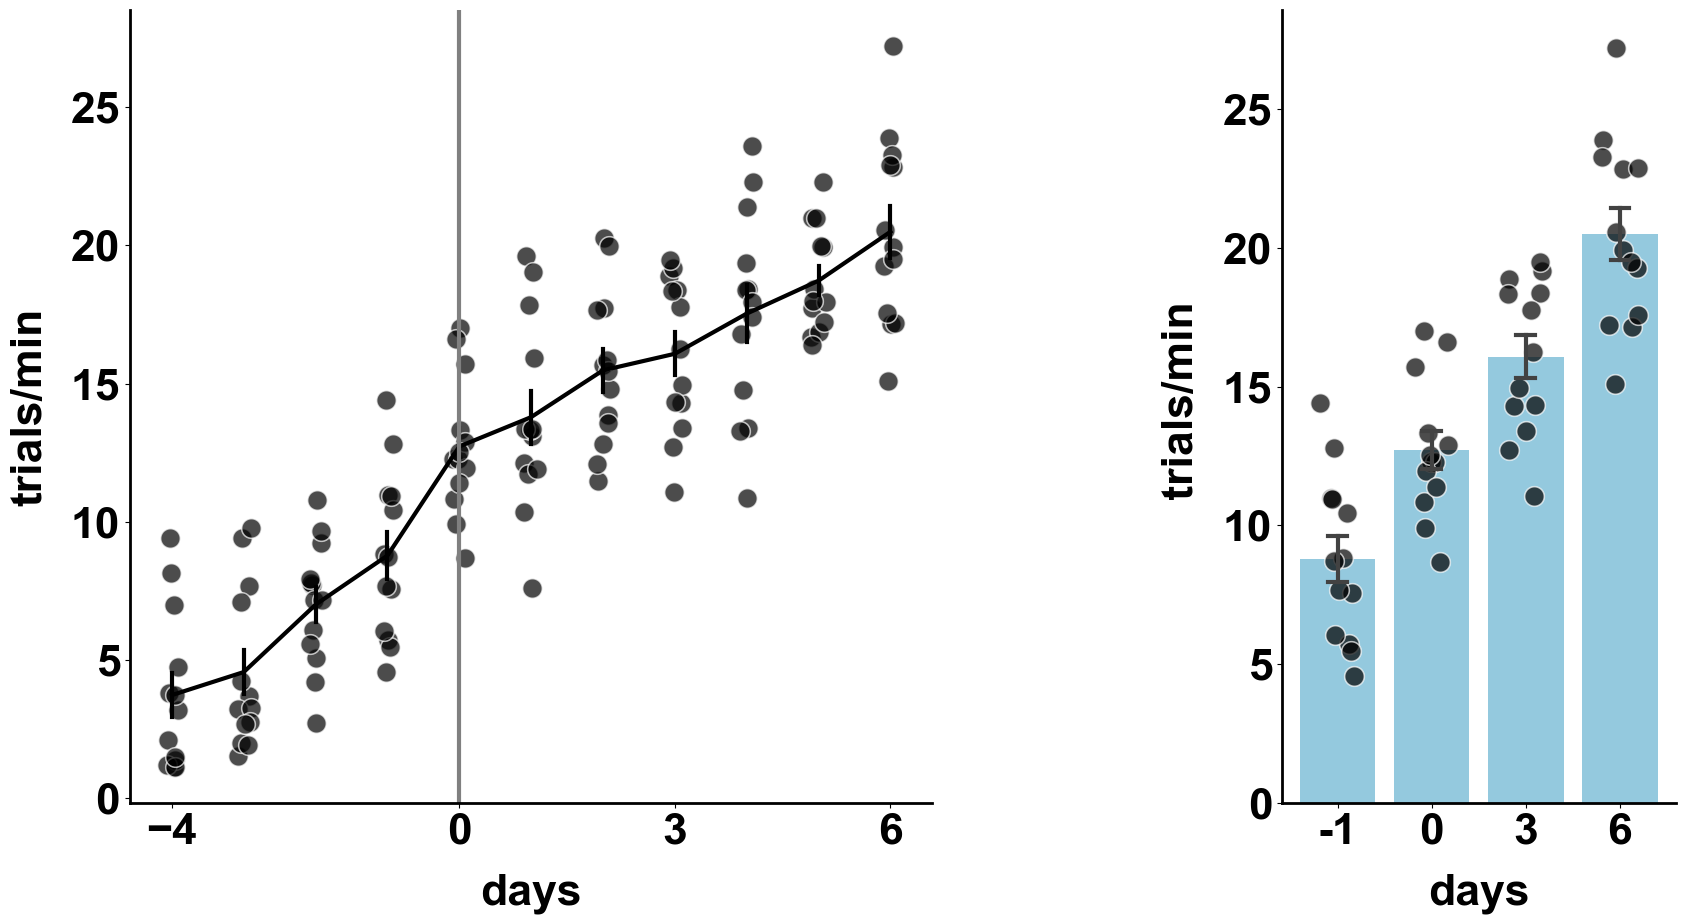

In [73]:
# Set global font properties

plt.rcParams.update({
    'font.size': 32,
    'font.weight': 'bold',
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

line = light_trial_permin[(light_trial_permin.date_index >= -4) & (light_trial_permin.date_index <= 6)]
plt.rc('axes', edgecolor='black')

# Create larger figure
fig = plt.figure(figsize=(20, 10))

# Use GridSpec with adjusted spacing - now with more space for y-axis labels
gs = GridSpec(1, 6, figure=fig, width_ratios=[4, 0.5, 0.1, 0.1, 1.5, 0.5])  # Added more space on both sides
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 3:5], sharey=None)  # Explicitly no shared axis

# Remove top and right spines
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)

# Set labels with padding
ax1.set_xlabel('days', fontweight='bold', labelpad=15)
ax1.set_ylabel('trials/min', fontweight='bold', labelpad=15)
ax2.set_xlabel('days', fontweight='bold', labelpad=15)
ax2.set_ylabel(' trials/min', fontweight='bold', labelpad=15)  # Keep y-label for second plot

# Calculate individual animal means
individual_means = line.groupby(['date_index', 'animal'])['trialpermin'].mean().reset_index()
individual_means['jittered_x'] = individual_means['date_index'] + np.random.uniform(-0.1, 0.1, size=len(individual_means))

# Line plot
sns.lineplot(ax=ax1, data=line, x='date_index', y='trialpermin', 
             errorbar='se', err_style='bars', color='black', 
             linewidth=3, err_kws={'linewidth': 3})
sns.scatterplot(ax=ax1, data=individual_means, x='jittered_x', y='trialpermin', 
                color='black', s=200, alpha=0.7)
ax1.axvline(0, color='grey', ls='-', linewidth=3)
ax1.set_xticks([-4, 0, 3, 6])

# Bar plot data
bar = light_trial_permin[(light_trial_permin.date_index.isin([-1.0,0.0, 3.0, 6.0]))]
bar_individual_means = bar.groupby(['date_index', 'animal'])['trialpermin'].mean().reset_index()

# Bar plot - now with independent y-axis
sns.barplot(ax=ax2, data=bar, x='date_index', y='trialpermin', 
            errorbar='se', color='skyblue', 
            errwidth=3, linewidth=3, capsize=0.2)

# Add jittered points
date_to_pos = {-1.0:0,0.0: 1, 3.0: 2, 6.0: 3}
bar_individual_means['x_pos'] = bar_individual_means['date_index'].map(date_to_pos)
bar_individual_means['jittered_x'] = bar_individual_means['x_pos'] + np.random.uniform(-0.2, 0.2, size=len(bar_individual_means))
sns.scatterplot(ax=ax2, data=bar_individual_means, x='jittered_x', y='trialpermin', 
                color='black', s=200, alpha=0.7)

# Adjust bar plot ticks
ax2.set_xticks([0, 1, 2,3])
ax2.set_xticklabels([-1,0, 3, 6])

# Make all text bold
for ax in [ax1, ax2]:
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
                 ax.get_xticklabels() + ax.get_yticklabels()):
        item.set_fontweight('bold')

# Adjust layout with even more space between plots
plt.subplots_adjust(wspace=1.0)  # Increased space between subplots
plt.tight_layout()
#fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\trial_duration.pdf',dpi = 300)

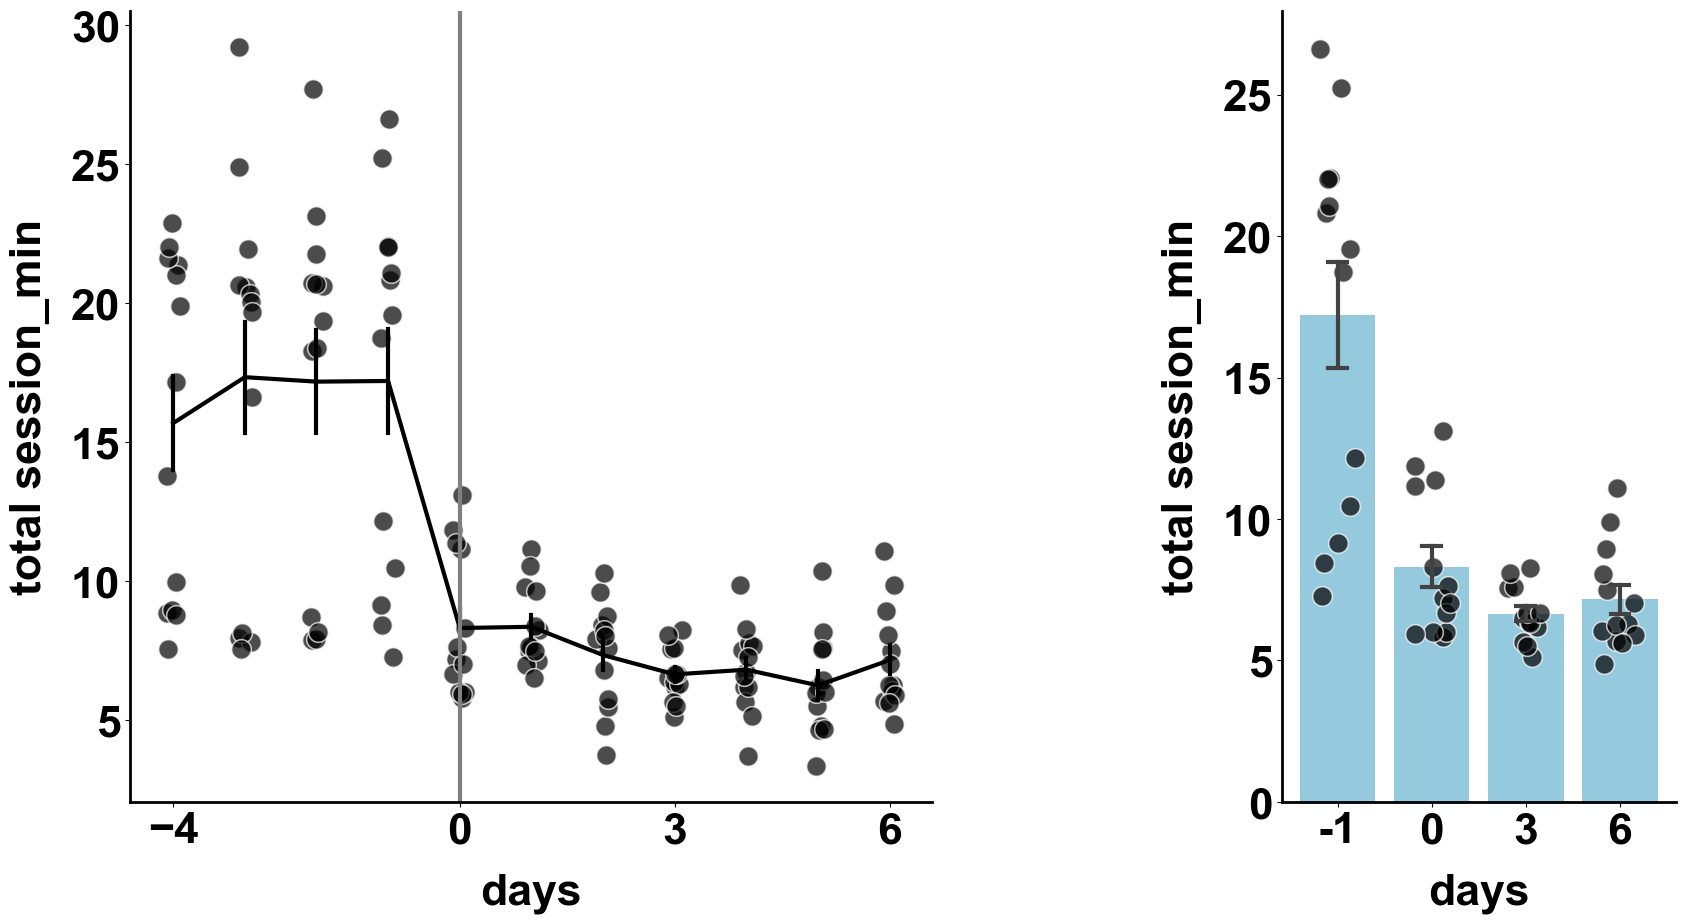

In [72]:
# Set global font properties

plt.rcParams.update({
    'font.size': 32,
    'font.weight': 'bold',
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

line = light_trial_permin[(light_trial_permin.date_index >= -4) & (light_trial_permin.date_index <= 6)]
plt.rc('axes', edgecolor='black')

# Create larger figure
fig = plt.figure(figsize=(20, 10))

# Use GridSpec with adjusted spacing - now with more space for y-axis labels
gs = GridSpec(1, 6, figure=fig, width_ratios=[4, 0.5, 0.1, 0.1, 1.5, 0.5])  # Added more space on both sides
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 3:5], sharey=None)  # Explicitly no shared axis

# Remove top and right spines
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)

# Set labels with padding
ax1.set_xlabel('days', fontweight='bold', labelpad=15)
ax1.set_ylabel('total session_min', fontweight='bold', labelpad=15)
ax2.set_xlabel('days', fontweight='bold', labelpad=15)
ax2.set_ylabel('total session_min', fontweight='bold', labelpad=15)  # Keep y-label for second plot

# Calculate individual animal means
individual_means = line.groupby(['date_index', 'animal'])['session_min'].mean().reset_index()
individual_means['jittered_x'] = individual_means['date_index'] + np.random.uniform(-0.1, 0.1, size=len(individual_means))

# Line plot
sns.lineplot(ax=ax1, data=line, x='date_index', y='session_min', 
             errorbar='se', err_style='bars', color='black', 
             linewidth=3, err_kws={'linewidth': 3})
sns.scatterplot(ax=ax1, data=individual_means, x='jittered_x', y='session_min', 
                color='black', s=200, alpha=0.7)
ax1.axvline(0, color='grey', ls='-', linewidth=3)
ax1.set_xticks([-4, 0, 3, 6])

# Bar plot data
bar = light_trial_permin[(light_trial_permin.date_index.isin([-1.0,0.0, 3.0, 6.0]))]
bar_individual_means = bar.groupby(['date_index', 'animal'])['session_min'].mean().reset_index()

# Bar plot - now with independent y-axis
sns.barplot(ax=ax2, data=bar, x='date_index', y='session_min', 
            errorbar='se', color='skyblue', 
            errwidth=3, linewidth=3, capsize=0.2)

# Add jittered points
date_to_pos = {-1.0:0,0.0: 1, 3.0: 2, 6.0: 3}
bar_individual_means['x_pos'] = bar_individual_means['date_index'].map(date_to_pos)
bar_individual_means['jittered_x'] = bar_individual_means['x_pos'] + np.random.uniform(-0.2, 0.2, size=len(bar_individual_means))
sns.scatterplot(ax=ax2, data=bar_individual_means, x='jittered_x', y='session_min', 
                color='black', s=200, alpha=0.7)

# Adjust bar plot ticks
ax2.set_xticks([0, 1, 2,3])
ax2.set_xticklabels([-1,0, 3, 6])

# Make all text bold
for ax in [ax1, ax2]:
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
                 ax.get_xticklabels() + ax.get_yticklabels()):
        item.set_fontweight('bold')

# Adjust layout with even more space between plots
plt.subplots_adjust(wspace=1.0)  # Increased space between subplots
plt.tight_layout()